# Distribution Network Optimization – Data Preparation (Part 1)

In this notebook I prepare and explore the input data for the case study:

- Load and clean the raw 2017 shipment data (`Expedition` sheet).
- Load and clean the distance matrix (distances from sites Z1–Z3 to each customer).
- Compute ton-km and merge everything into a unified table (`expedition1`).
- Analyze how customers used Train vs Truck in 2017.
- Build a helper table that shows, for each (customer, site), whether Train/Truck connections actually existed in 2017.

Later, this cleaned data will be used to build and solve a linear optimization model in Python (PuLP) to minimize total transport cost while respecting realistic constraints.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import plotly.express as px
import plotly.graph_objects as go

import pulp
from pulp import value as pulp_value

import math
import time

# Use a clean style for matplotlib
plt.style.use("ggplot")
pd.options.display.float_format = "{:,.2f}".format


## 1. Load and clean the input data

I work with one Excel file:

- **`Expedition` sheet** – all shipments in 2017: date, site (Z1–Z3 or others), customer, mode (Train/Truck), weight.
- **`Distance Matrix` sheet** – distance in km from each site to each customer.

In this section I:
1. Load both sheets.
2. Clean column names and data types.
3. Parse dates and convert weights to numeric.
4. Build a distance lookup table for later use.


In [2]:
# 1. Load and clean the data

FILE_PATH = "Case Study - distribution.xlsx"  # change if your file is named differently

# ---------- Expedition sheet ----------
expedition = pd.read_excel(FILE_PATH, sheet_name="Expedition")

# Clean column names
expedition.columns = (
    expedition.columns.str.strip()
    .str.replace("\n", " ")
    .str.replace("\r", " ")
)

expedition.head()


,Expedition date,Material,Train/Truck,Weight[t],Site,Customer
0,2017-01-01 19:37:35,M1,Train,1239,Z1,81
1,2017-01-01 19:37:35,M1,Train,1568,Z1,81
2,2017-01-01 19:37:35,M1,Train,1492,Z2,50
3,2017-01-01 19:37:35,M1,Train,1479,Z2,26
4,2017-01-02 00:54:34,M1,Train,742,Z2,19


In [3]:
out_of_z1_z3 = expedition[
    (expedition["Site"] != "Z1") &
    (expedition["Site"] != "Z2") &
    (expedition["Site"] != "Z3")
]

out_of_z1_z3

,Expedition date,Material,Train/Truck,Weight[t],Site,Customer
1145,2017-01-07 01:27:05,M1,Train,49,NaN,4
1592,2017-01-09 12:31:18,M1,Train,1192,NaN,0
1593,2017-01-09 12:31:18,M1,Train,1192,NaN,0
1594,2017-01-09 12:31:18,M1,Train,1192,NaN,0
1595,2017-01-09 12:31:18,M1,Train,1060,NaN,0
...,...,...,...,...,...,...
68470,2017-11-20 16:10:40,M1,Train,147,NaN,0
69689,2017-11-26 05:45:12,M1,Train,123,NaN,0
71861,2017-12-05 23:50:34,M1,Train,94,NaN,0
71862,2017-12-05 23:50:34,M1,Train,94,NaN,0


In [4]:
# 1.1 Clean the Expedition data

# Parse date (ignore time)
expedition["Expedition date"] = pd.to_datetime(expedition["Expedition date"]).dt.date

# Clean weight: remove spaces / commas and cast to float
expedition["Weight[t]"] = (
    expedition["Weight[t]"]
    .astype(str)
    .str.replace(" ", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Clean text columns
for col in ["Train/Truck", "Site", "Customer"]:
    expedition[col] = expedition[col].astype(str).str.strip()

# Convert Customer to integer for easier grouping
expedition["Customer"] = expedition["Customer"].astype(int)

expedition.info()
expedition.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74374 entries, 0 to 74373
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Expedition date  74374 non-null  object 
 1   Material         74374 non-null  object 
 2   Train/Truck      74374 non-null  object 
 3   Weight[t]        74374 non-null  float64
 4   Site             74374 non-null  object 
 5   Customer         74374 non-null  int32  
dtypes: float64(1), int32(1), object(4)
memory usage: 3.1+ MB


,Expedition date,Material,Train/Truck,Weight[t],Site,Customer
0,2017-01-01,M1,Train,"1,239.00",Z1,81
1,2017-01-01,M1,Train,"1,568.00",Z1,81
2,2017-01-01,M1,Train,"1,492.00",Z2,50
3,2017-01-01,M1,Train,"1,479.00",Z2,26
4,2017-01-02,M1,Train,742.00,Z2,19


### 1.2 Distance Matrix: site–customer distances

Now I load the **Distance Matrix** sheet, which contains:

- `Customer`
- `Site`
- `Distance (km)`

I clean it and convert it into a convenient dictionary `(Customer, Site) → Distance_km` that I’ll later use in the optimization model.


In [5]:
# 1.2 ---------- Distance Matrix sheet ----------

dist_mat = pd.read_excel(FILE_PATH, sheet_name="Distance Matrix")

dist_mat.columns = dist_mat.columns.str.strip()
dist_mat["Customer"] = dist_mat["Customer"].astype(int)
dist_mat["Site"] = dist_mat["Site"].astype(str).str.strip()
dist_mat["Distance (km)"] = (
    dist_mat["Distance (km)"]
    .astype(str)
    .str.replace(" ", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
    .replace(0, 1)        # change any 0 distance to 1
)

dist_mat.head()


,Customer,Site,Distance (km)
0,0,Z1,103.00
1,0,Z2,237.00
2,0,Z3,17.00
3,1,Z1,171.00
4,1,Z2,416.00


### 1.3 Distance lookup dictionary

For faster calculations later, I build a dictionary:

\\[
\text{distance\_lookup}[(\text{customer}, \text{site})] = \text{distance in km}
\\]


In [6]:
# 1.3 distance dict
distance_lookup = dist_mat.set_index(["Customer", "Site"])["Distance (km)"].to_dict()
distance_lookup

{(0, 'Z1'): 103.0,
 (0, 'Z2'): 237.0,
 (0, 'Z3'): 17.0,
 (1, 'Z1'): 171.0,
 (1, 'Z2'): 416.0,
 (1, 'Z3'): 211.0,
 (2, 'Z1'): 274.0,
 (2, 'Z2'): 30.0,
 (2, 'Z3'): 14.0,
 (3, 'Z1'): 494.0,
 (3, 'Z2'): 309.0,
 (3, 'Z3'): 5.0,
 (4, 'Z1'): 224.0,
 (4, 'Z2'): 225.0,
 (4, 'Z3'): 426.0,
 (5, 'Z1'): 168.0,
 (5, 'Z2'): 240.0,
 (5, 'Z3'): 389.0,
 (6, 'Z1'): 21.0,
 (6, 'Z2'): 291.0,
 (6, 'Z3'): 310.0,
 (7, 'Z1'): 348.0,
 (7, 'Z2'): 330.0,
 (7, 'Z3'): 262.0,
 (8, 'Z1'): 163.0,
 (8, 'Z2'): 298.0,
 (8, 'Z3'): 424.0,
 (9, 'Z1'): 332.0,
 (9, 'Z2'): 14.0,
 (9, 'Z3'): 486.0,
 (10, 'Z1'): 443.0,
 (10, 'Z2'): 141.0,
 (10, 'Z3'): 279.0,
 (11, 'Z1'): 87.0,
 (11, 'Z2'): 209.0,
 (11, 'Z3'): 215.0,
 (12, 'Z1'): 215.0,
 (12, 'Z2'): 327.0,
 (12, 'Z3'): 25.0,
 (13, 'Z1'): 139.0,
 (13, 'Z2'): 46.0,
 (13, 'Z3'): 12.0,
 (14, 'Z1'): 376.0,
 (14, 'Z2'): 209.0,
 (14, 'Z3'): 221.0,
 (15, 'Z1'): 295.0,
 (15, 'Z2'): 55.0,
 (15, 'Z3'): 163.0,
 (16, 'Z1'): 336.0,
 (16, 'Z2'): 96.0,
 (16, 'Z3'): 448.0,
 (17, 'Z1'): 370.0,
 (1

### 1.4 Merge distances into shipments and compute ton-km

I merge the distances into the expedition data to obtain a single table `expedition1` with:

- all original shipment information,
- distance from the serving site to the customer,
- `ton_km = tonnes × distance`.

This will be the main input for both descriptive analysis and the optimization model.


In [7]:
# 1.4 Merge distances into the expedition table:

expedition1 = expedition.merge(
    dist_mat,
    on=["Customer", "Site"],
    how="left",
    validate="many_to_one"
)

expedition1.rename(columns={"Distance (km)": "Distance_km"}, inplace=True)
expedition1["ton_km"] = expedition1["Weight[t]"] * expedition1["Distance_km"]

expedition1.head()


,Expedition date,Material,Train/Truck,Weight[t],Site,Customer,Distance_km,ton_km
0,2017-01-01,M1,Train,"1,239.00",Z1,81,294.00,"364,266.00"
1,2017-01-01,M1,Train,"1,568.00",Z1,81,294.00,"460,992.00"
2,2017-01-01,M1,Train,"1,492.00",Z2,50,495.00,"738,540.00"
3,2017-01-01,M1,Train,"1,479.00",Z2,26,95.00,"140,505.00"
4,2017-01-02,M1,Train,742.00,Z2,19,139.00,"103,138.00"


## 1.5 Mode usage per customer (Train vs Truck)

First, I want to understand **how each customer used Train and Truck in 2017**:

- total tonnes by (Customer, Mode),
- share of Train vs Truck per customer,
- and a bar plot showing these percentages.

This will later be used to create constraints: for most customers I allow only a small deviation (±5 percentage points) from their original Train/Truck mix.


In [8]:
# 1.5 Sum tonnes by Customer + mode
cust_mode = (
    expedition1
    .groupby(["Customer", "Train/Truck"])["Weight[t]"]
    .sum()
    .reset_index()
)

# Compute % share within each customer
cust_mode["Share_pct"] = (
    cust_mode.groupby("Customer")["Weight[t]"]
    .transform(lambda x: x / x.sum() * 100)
)

# Wide table: tonnes + % for each mode per customer
tonnes_wide = (
    cust_mode
    .pivot(index="Customer", columns="Train/Truck", values="Weight[t]")
    .fillna(0)
    .add_suffix("_t")       # Train_t, Truck_t
)

pct_wide = (
    cust_mode
    .pivot(index="Customer", columns="Train/Truck", values="Share_pct")
    .fillna(0)
    .round(1)
    .add_suffix("_pct")     # Train_pct, Truck_pct
)

customer_mode_table = (
    pd.concat([tonnes_wide, pct_wide], axis=1)
    .reset_index()
)

customer_mode_table.head()


Train/Truck,Customer,Train_t,Truck_t,Train_pct,Truck_pct
0,0,"92,842.00","38,532.00",70.70,29.30
1,1,"1,095,233.00","107,861.00",91.00,9.00
2,2,"592,850.00","65,233.00",90.10,9.90
3,3,"517,578.00","91,799.00",84.90,15.10
4,4,"448,481.00","89,447.00",83.40,16.60


### 1.5.1 Plot: Train/Truck share per customer

This Plotly chart shows, for each customer, what percentage of their 2017 volume went by Train vs Truck.


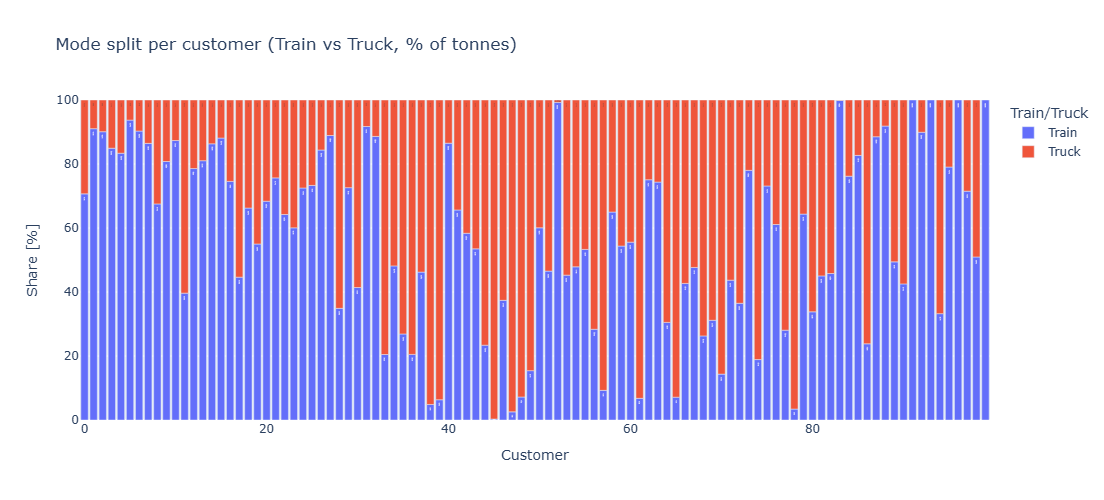

In [9]:
# 1.5.1 Plotly bar – mode split per customer

# Nice label for percentages
cust_mode["Share_label"] = cust_mode["Share_pct"].round(1).astype(str) + "%"

fig = px.bar(
    cust_mode,
    x="Customer",
    y="Share_pct",
    color="Train/Truck",
    title="Mode split per customer (Train vs Truck, % of tonnes)",
    text="Share_label",
    width=1100,
    height=500
)

fig.update_traces(textposition="inside")
fig.update_yaxes(title="Share [%]", range=[0, 100])
fig.update_layout(
    bargap=0.15,
    bargroupgap=0.05
)

fig.show()
fig.write_image("mode_split_per_cust_2017.png", width=1600, height=900, scale=3)


## 1.6 Feasible customer–site–mode combinations (Train/Truck)

For the optimization model I must **not** allow the algorithm to invent transport combinations that never existed in 2017.

So I build a helper table that shows, for every (customer, site):

- whether Train was used at least once (`Train_exists` = YES/NO),
- whether Truck was used at least once (`Truck_exists` = YES/NO).

Later, any (customer, site, mode) with `NO` will get a constraint `flow = 0` in the PuLP model.


In [10]:
# 1.6 We only care about shipments to the three modeled sites
model_sites = ["Z1", "Z2", "Z3"]

# 1) Build a table that says: for each (Customer, Site, Mode) did we ever ship anything?
#    I don't care about the exact tonnes, just existence (yes/no).

exp_modes = (
    expedition1[expedition1["Site"].isin(model_sites)]
    .assign(has_shipment=1)
    .groupby(["Customer", "Site", "Train/Truck"])["has_shipment"]
    .max()                      # 1 if at least one such shipment exists
    .unstack(fill_value=0)      # columns: 'Train', 'Truck' (or whatever appears)
)

# Ensure both columns exist even if one mode is missing entirely
for m in ["Train", "Truck"]:
    if m not in exp_modes.columns:
        exp_modes[m] = 0

exp_modes = exp_modes[["Train", "Truck"]].reset_index()

# 2) Create full Customer×Site grid so you see also combinations that had no shipments at all

customers = sorted(expedition1["Customer"].unique())
sites = model_sites

full_grid = (
    pd.MultiIndex.from_product([customers, sites], names=["Customer", "Site"])
    .to_frame(index=False)
)

# 3) Merge presence info onto full grid; missing -> 0 (NO)
presence = full_grid.merge(exp_modes, on=["Customer", "Site"], how="left").fillna(0)

# 4) Convert 0/1 to "NO"/"YES" flags
presence["Train_exists"] = np.where(presence["Train"] > 0, "YES", "NO")
presence["Truck_exists"] = np.where(presence["Truck"] > 0, "YES", "NO")

# Keep only the YES/NO view
presence = presence[["Customer", "Site", "Train_exists", "Truck_exists"]]

# 5) Sort so that rows with any "NO" appear on the top
presence["missing_any"] = (presence["Train_exists"] == "NO") | (presence["Truck_exists"] == "NO")

presence_sorted = (
    presence
    .sort_values(["missing_any", "Customer", "Site"], ascending=[False, True, True])
    .drop(columns="missing_any")
    .reset_index(drop=True)
)

# This is the final helper table:
presence_sorted.head()


,Customer,Site,Train_exists,Truck_exists
0,0,Z1,YES,NO
1,0,Z3,NO,YES
2,1,Z1,YES,NO
3,2,Z1,YES,NO
4,3,Z1,YES,NO


## 2. Descriptive analysis of the 2017 distribution network

In this section I answer a few key questions about the **current (2017)** situation:

- How much volume does each site (Z1, Z2, Z3) handle vs its capacity?
- What is the Train vs Truck split for each site?
- Who are the top customers by tonnage?
- Which customers are served from **non-closest** sites (extra ton-km)?
- How do the main flows from sites to customers look (Sankey view)?

This gives us a clear understanding of the weak spots before building the optimization model.


### 2.1 Site capacities and utilization (2017)

First, I compare **actual 2017 volumes** vs **site capacities**:

- I compute total tonnes shipped from each site.
- I compare it to the annual capacity to get utilization %.
- Then I visualize it with a grouped bar chart.


In [11]:
# 2. Basic aggregates (2017)
# 2.1.1 Site capacities and utilization

site_capacity = {
    "Z1": 5_774_700,
    "Z2": 15_478_400,
    "Z3": 5_734_900,
}

site_volume = expedition1.groupby("Site")["Weight[t]"].sum()
site_df = pd.DataFrame({
    "Volume_t": site_volume,
    "Capacity_t": pd.Series(site_capacity)
})
site_df["Utilization_%"] = 100 * site_df["Volume_t"] / site_df["Capacity_t"]
site_df


,Volume_t,Capacity_t,Utilization_%
Z1,"2,736,861.00","5,774,700.00",47.39
Z2,"15,174,975.00","15,478,400.00",98.04
Z3,"1,792,159.00","5,734,900.00",31.25
nan,"25,333.00",NaN,NaN


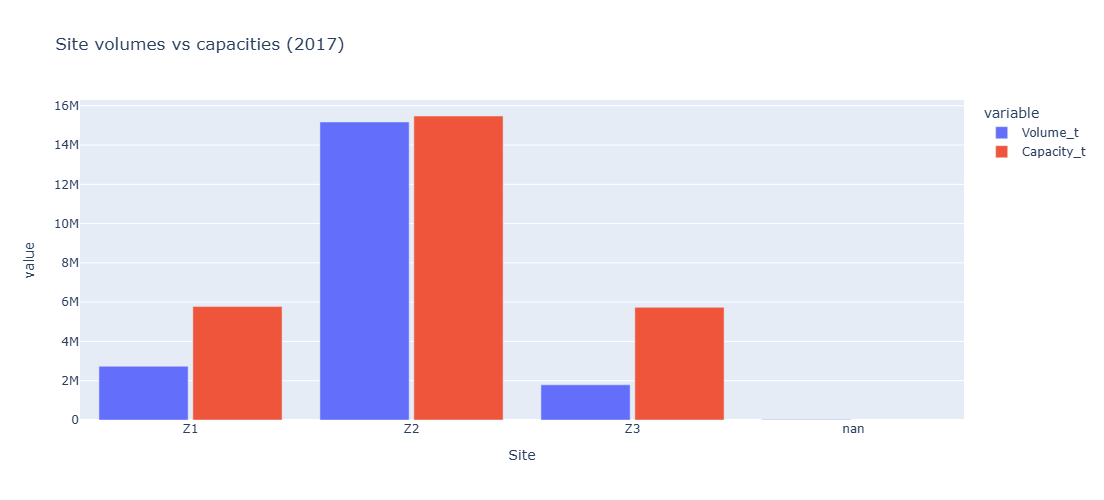

In [12]:
# 2.1.2 Plotly version – volumes vs capacities

site_df = site_df.copy()
site_df.index.name = "Site"

plot_df = site_df.reset_index()
plot_df = plot_df[plot_df["Site"].notna()]

fig = px.bar(
    plot_df,
    x="Site",
    y=["Volume_t", "Capacity_t"],
    barmode="group",
    title="Site volumes vs capacities (2017)",
    width=900,
    height=500
)

fig.update_layout(
    bargap=0.15,
    bargroupgap=0.05
)

fig.show()
fig.write_image("site_volume_vs_capacities_2017.png", width=1600, height=900, scale=3)


### 2.2 Mode split per site (Train vs Truck)

Next, I analyze **how each site uses Train vs Truck**:

- Z1 is almost 100% Train.
- Z3 is mostly Truck (~92%).
- These site-level proportions will later be kept (±3 percentage points) in the optimization so the solution stays realistic.


In [13]:
# 2.2 Split by transport mode (Train vs Truck)

mode_site = (
    expedition1
    .groupby(["Site", "Train/Truck"])["Weight[t]"]
    .sum()
    .reset_index()
    .rename(columns={"Weight[t]": "Tonnes"})
)
mode_site


,Site,Train/Truck,Tonnes
0,Z1,Train,"2,736,861.00"
1,Z2,Train,"9,441,758.00"
2,Z2,Truck,"5,733,217.00"
3,Z3,Train,"129,916.00"
4,Z3,Truck,"1,662,243.00"
5,nan,Train,"25,333.00"


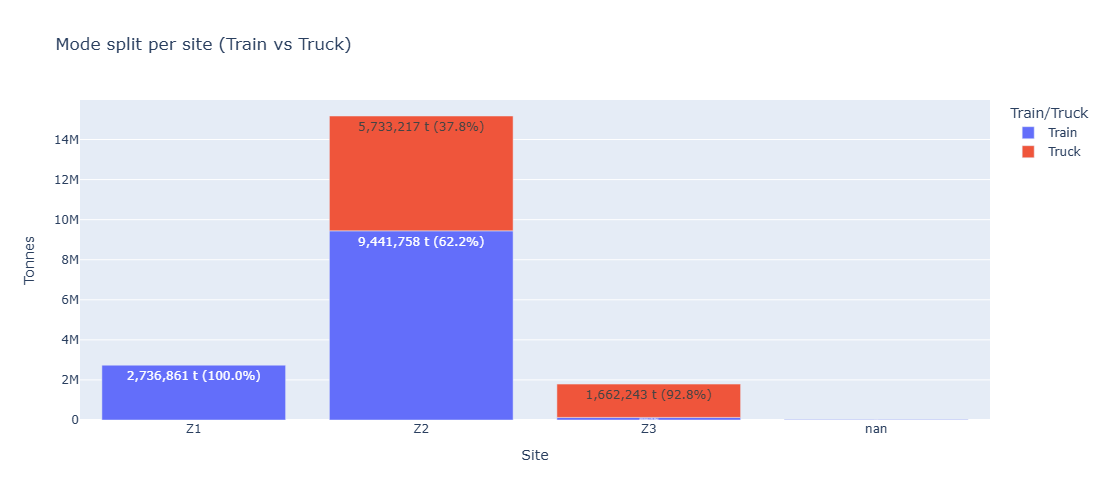

In [14]:
# 2.2.1 Plotly stacked bar – absolute tonnes

# copy + compute % share within each Site
mode_site2 = mode_site.copy()
mode_site2["Pct"] = (
    mode_site2.groupby("Site")["Tonnes"]
    .transform(lambda x: x / x.sum() * 100)
)

# nice text: "2 736 861 t (100.0%)"
mode_site2["Text"] = mode_site2.apply(
    lambda r: f"{r['Tonnes']:,.0f} t\n({r['Pct']:.1f}%)",
    axis=1
)

fig = px.bar(
    mode_site2,
    x="Site",
    y="Tonnes",
    color="Train/Truck",
    title="Mode split per site (Train vs Truck)",
    text="Text",
    width=900,
    height=500
)

fig.update_traces(textposition="inside")   # put labels inside bars

fig.update_layout(
    bargap=0.15,
    bargroupgap=0.05
)

fig.show()
#fig.write_image("mode_split_per_site_2017.png", width=1600, height=900, scale=3)


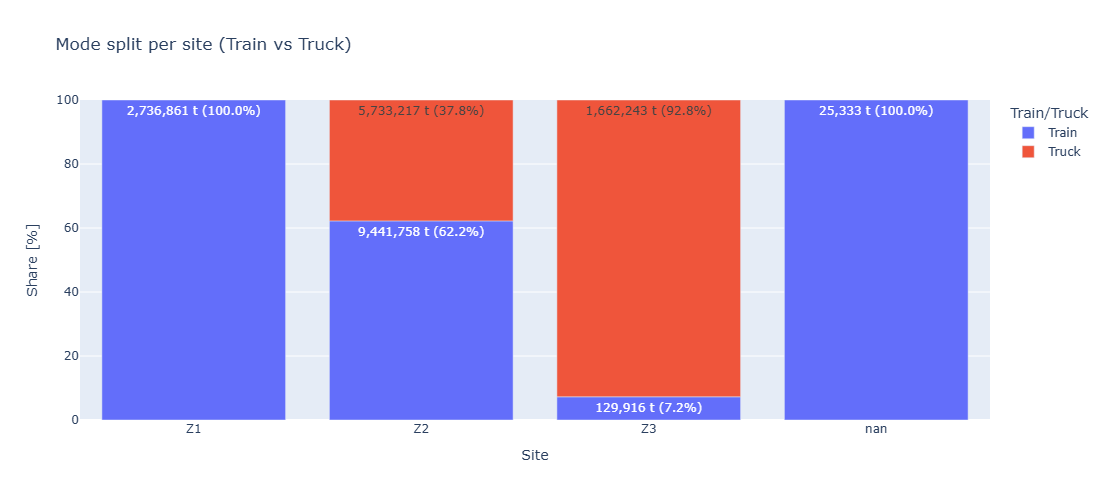

In [15]:
# 2.2.2 100% stacked bar – percentage share per site

# copy + drop the total/NaN site if needed
mode_site2 = mode_site.copy()
mode_site2 = mode_site2[mode_site2["Site"].notna()]

# share of tonnes within each site (in %)
mode_site2["Pct"] = (
    mode_site2.groupby("Site")["Tonnes"]
    .transform(lambda x: x / x.sum() * 100)
)

# nice label: "2 736 861 t (100.0%)"
mode_site2["Text"] = mode_site2.apply(
    lambda r: f"{r['Tonnes']:,.0f} t\n({r['Pct']:.1f}%)",
    axis=1
)

fig = px.bar(
    mode_site2,
    x="Site",
    y="Pct",              # plot percentages so each site sums to 100
    color="Train/Truck",
    title="Mode split per site (Train vs Truck)",
    text="Text",          # show tonnes + %
    width=900,
    height=500
)

fig.update_traces(textposition="inside")

fig.update_layout(
    bargap=0.15,
    bargroupgap=0.05,
)

fig.update_yaxes(title="Share [%]", range=[0, 100])

fig.show()
fig.write_image("mode_split_per_site_percent_2017.png", width=1600, height=900, scale=3)


### 2.3 Top customers by shipped tonnage

Here I identify the **top 20 customers by total tonnes in 2017**.

These customers typically drive most of the volume and cost, so they are especially important for optimization and later reporting.


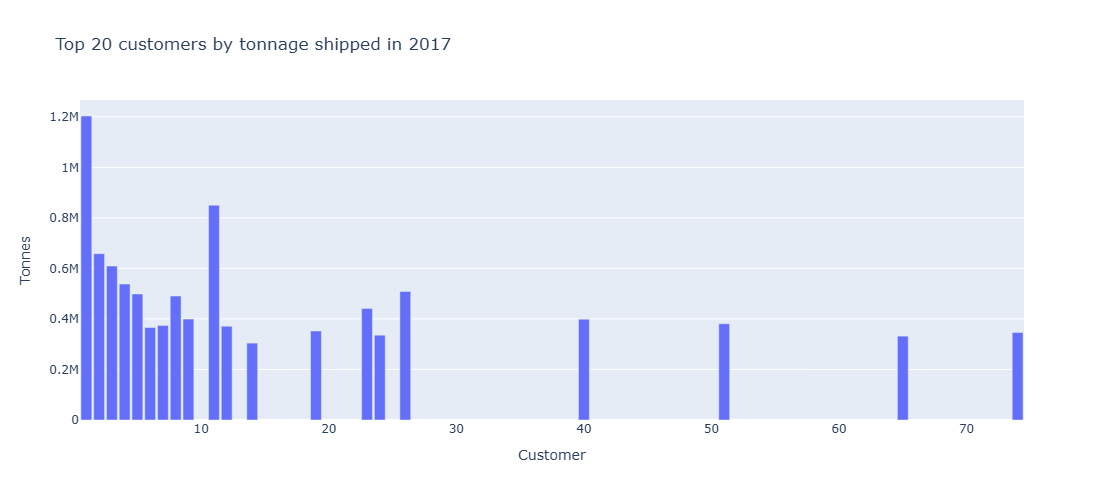

In [16]:
# 2.3 Top customers by volume

customer_volume = (
    expedition1.groupby("Customer")["Weight[t]"]
    .sum()
    .sort_values(ascending=False)
)

top_n = 20
top_cust = customer_volume.head(top_n).reset_index()

fig = px.bar(
    top_cust,
    x="Customer",
    y="Weight[t]",
    title=f"Top {top_n} customers by tonnage shipped in 2017",
    labels={"Weight[t]": "Tonnes"},
    width=1000,
    height=500
)

fig.update_layout(
    bargap=0.15,
)

fig.show()
fig.write_image("customers_with_largest_tonnage_2017.png", width=1600, height=900, scale=3)


### 2.4 Extra distance vs closest site (inefficient assignments)

To see where the current network is **inefficient**, I compare:

- the **actual distance** used in 2017, vs
- the **minimum possible distance** from any site to that customer.

For each shipment I compute:

- `ExtraDistance_km = ActualDistance_km – MinDistance_km`,
- `Extra_ton_km = Weight × ExtraDistance_km`.

Then I aggregate extra ton-km per customer to see which customers are served from non-closest sites.


In [17]:
# 2.4 Distance & “inefficient assignment” analysis

"""
For each shipment I compare the actual distance from the used site with
the minimum possible distance from any site → extra distance & extra ton-km.
"""

# Min possible distance by customer
min_distance_per_customer = (
    dist_mat.groupby("Customer")["Distance (km)"].min()
    .rename("MinDistance_km")
)

expedition2 = expedition1.merge(
    min_distance_per_customer,
    on="Customer",
    how="left"
)

expedition2["ExtraDistance_km"] = expedition2["Distance_km"] - expedition2["MinDistance_km"]
expedition2["ExtraDistance_km"] = expedition2["ExtraDistance_km"].clip(lower=0)

expedition2["Extra_ton_km"] = expedition2["Weight[t]"] * expedition2["ExtraDistance_km"]
expedition2.head()


,Expedition date,Material,Train/Truck,Weight[t],Site,Customer,Distance_km,ton_km,MinDistance_km,ExtraDistance_km,Extra_ton_km
0,2017-01-01,M1,Train,"1,239.00",Z1,81,294.00,"364,266.00",208.00,86.00,"106,554.00"
1,2017-01-01,M1,Train,"1,568.00",Z1,81,294.00,"460,992.00",208.00,86.00,"134,848.00"
2,2017-01-01,M1,Train,"1,492.00",Z2,50,495.00,"738,540.00",271.00,224.00,"334,208.00"
3,2017-01-01,M1,Train,"1,479.00",Z2,26,95.00,"140,505.00",95.00,0.00,0.00
4,2017-01-02,M1,Train,742.00,Z2,19,139.00,"103,138.00",139.00,0.00,0.00


In [18]:
# 2.4.1 Aggregate extra ton-km per customer to see where assignments look worst

ineff_per_cust = (
    expedition2.groupby("Customer")["Extra_ton_km"]
    .sum()
    .sort_values(ascending=False)
)

ineff_per_cust.head()


Customer
3    216,536,838.00
1    136,467,250.00
74   131,630,764.00
24    97,897,100.00
12    95,578,986.00
Name: Extra_ton_km, dtype: float64

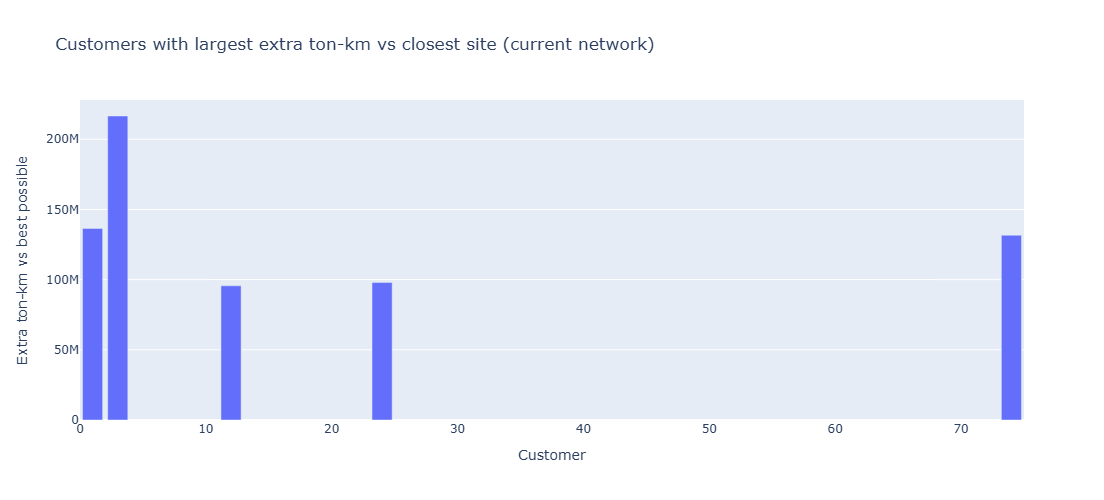

In [19]:
# 2.4.2 Plot top 20 "worst" customers by extra ton-km

ineff_top = ineff_per_cust.head().reset_index()

fig = px.bar(
    ineff_top,
    x="Customer",
    y="Extra_ton_km",
    title="Customers with largest extra ton-km vs closest site (current network)",
    labels={"Extra_ton_km": "Extra ton-km vs best possible"},
    width=900,
    height=500
)
fig.show()

fig.write_image("customers_with_largest_extra_ton_km_2017.png", width=1600, height=900, scale=3)

# This graph shows customers that are currently served from a site that is not the closest one. 
# Those with large extra ton-km are good candidates for reassignment.


### 2.5 Simple network view (Sankey diagram)

Finally, I build a **Sankey diagram** to visualize the main flows:

- nodes on the left are sites (Z1, Z2, Z3),
- nodes on the right are the **top 20 customers** by tonnage,
- link width corresponds to shipped tonnes.

This gives an intuitive picture of which sites are feeding which big customers.


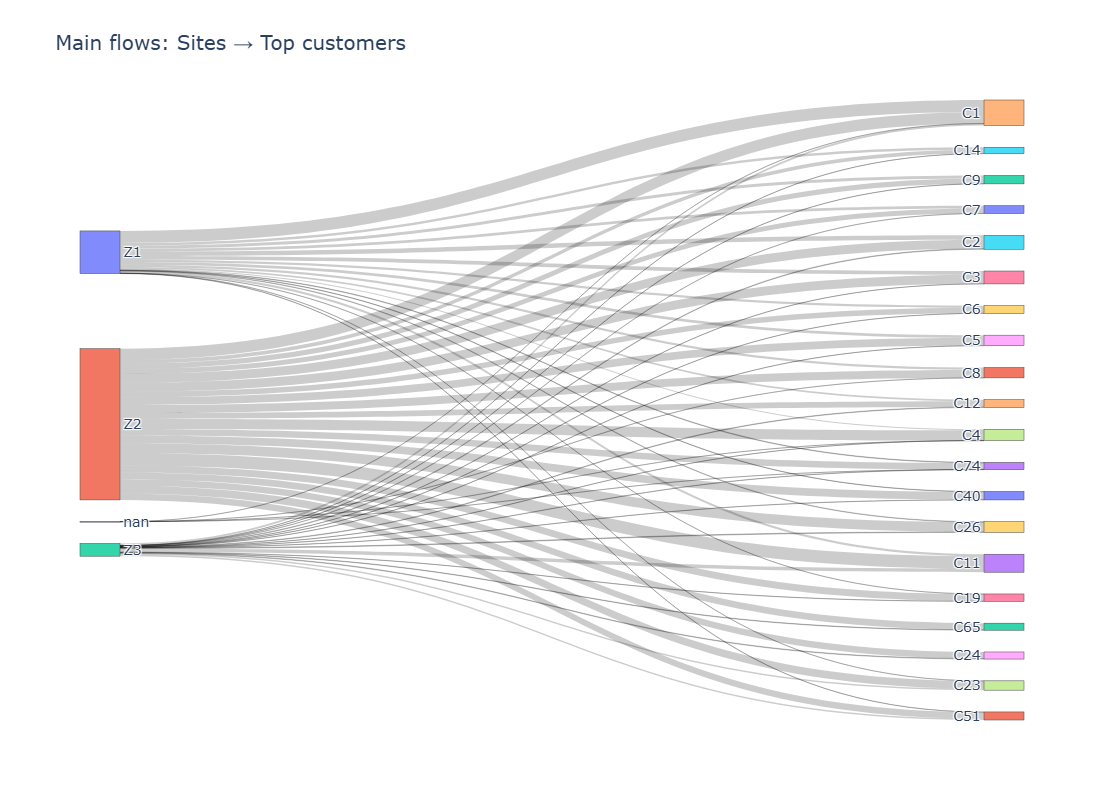

In [20]:
# 2.5 Simple network view (Sankey for top flows)

cust_site_flows = (
    expedition2.groupby(["Site", "Customer"])["Weight[t]"]
    .sum()
    .reset_index()
    .rename(columns={"Weight[t]": "Tonnes"})
)

# Only keep top N customers by volume to keep diagram readable
top_customers_for_sankey = (
    cust_site_flows.groupby("Customer")["Tonnes"]
    .sum()
    .nlargest(20)
    .index
)

cs_top = cust_site_flows[cust_site_flows["Customer"].isin(top_customers_for_sankey)]

sites = cs_top["Site"].unique().tolist()
customers = sorted(cs_top["Customer"].unique())

# Build node list: first sites, then customers
site_nodes = sites
customer_nodes = [f"C{c}" for c in customers]
nodes = site_nodes + customer_nodes

node_indices = {name: i for i, name in enumerate(nodes)}

sources = [node_indices[row["Site"]] for _, row in cs_top.iterrows()]
targets = [node_indices[f"C{row['Customer']}"] for _, row in cs_top.iterrows()]
values = cs_top["Tonnes"].tolist()

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=30,
        thickness=40,
        label=nodes,
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
)])

fig.update_layout(
    title_text="Main flows: Sites → Top customers",
    width=1100,
    height=800,
    font=dict(size=14)
)

fig.show()
fig.write_image("main_flows_site_top_cust_2017.png", width=1600, height=900, scale=3)


## 3. Cost assumptions and current cost (2017)

Before optimizing, I need to estimate the **current distribution cost**:

- I assume approximate 2017 unit costs:
  - **Truck**: 0.060 EUR per ton-km
  - **Train**: 0.035 EUR per ton-km
- Using `expedition2` (which already has `ton_km`), I compute:
  - total cost per shipment,
  - total cost and ton-km of the current network,
  - breakdown by mode and by site.

These numbers will be the baseline to compare with the optimized solution later.


In [21]:
# 3. Cost assumptions & current cost estimation (2017)

# Let’s assume EUR per ton-km (rough 2017 order of magnitude):
# Truck: 0.06 EUR/tkm
# Train: 0.035 EUR/tkm

COST_PER_TKM = {
    "Truck": 0.06,   # EUR per ton-km
    "Train": 0.035,  # EUR per ton-km
}

# Map unit cost to each row based on mode
expedition2["unit_cost_eur_per_tkm"] = expedition2["Train/Truck"].map(COST_PER_TKM)

# Cost = ton-km * unit cost
expedition2["Cost_EUR"] = expedition2["ton_km"] * expedition2["unit_cost_eur_per_tkm"]

total_cost_current = expedition2["Cost_EUR"].sum()
total_ton_km_current = expedition2["ton_km"].sum()

print(f"Total ton-km (current network): {total_ton_km_current:,.0f}")
print(f"Total estimated cost (current network): {total_cost_current:,.0f} EUR")


Total ton-km (current network): 4,744,118,621
Total estimated cost (current network): 207,688,409 EUR


### 3.1 Cost split by mode and site

Here I check:

- how much cost goes to **Train vs Truck**,
- how much cost is attributed to each **site (Z1–Z3)**,
- and I visualize the site-wise cost with a bar chart.


In [22]:
# 3.1 Split by mode and site:

cost_by_mode = expedition2.groupby("Train/Truck")["Cost_EUR"].sum()
cost_by_site = expedition2.groupby("Site")["Cost_EUR"].sum()

print("Cost by mode:\n", cost_by_mode)
print("\nCost by site:\n", cost_by_site)


Cost by mode:
 Train/Truck
Train   107,742,191.38
Truck    99,946,217.76
Name: Cost_EUR, dtype: float64

Cost by site:
 Site
Z1     24,155,972.33
Z2    164,201,992.24
Z3     19,330,444.57
nan             0.00
Name: Cost_EUR, dtype: float64


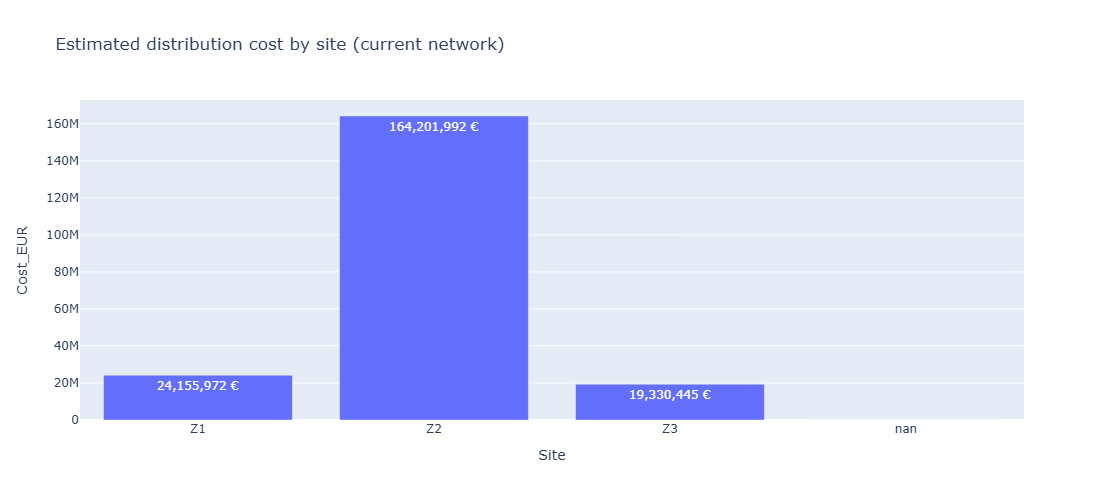

In [23]:
# 3.1.1 Plot cost per site

fig = px.bar(
    cost_by_site.reset_index(),
    x="Site",
    y="Cost_EUR",
    title="Estimated distribution cost by site (current network)",
    text="Cost_EUR",   # use this column as the base for text
    width=900,
    height=500
)

fig.update_traces(
    texttemplate="%{text:,.0f} €",  # number with thousands sep + euro sign
    textposition="inside"
)

fig.show()
fig.write_image("distribution_cost_2017.png", width=1600, height=900, scale=3)


## 4. Preparing data for the optimization model

To build a linear optimization model (with PuLP) I need:

- **Demand per customer**: how many tonnes each customer must receive in a year.
- **Site capacities**: maximum annual tonnage that can be shipped from Z1, Z2, Z3.
- **Distance lookup**: distance (km) for each (customer, site).
- **Allowed modes** and their **cost coefficients** (Train/Truck).
- Information about:
  - historical **Train/Truck shares** per customer,
  - customers that are effectively **Train-only** (served from “other” sites),
  - feasible (customer, site, mode) combinations.

All of this becomes input for the PuLP model in the next part.


In [24]:
# 4.1 Demand per customer

customer_demand = expedition2.groupby("Customer")["Weight[t]"].sum()
customer_demand.name = "Demand_t"

customer_demand.head()


Customer
0     131,374.00
1   1,203,094.00
2     658,083.00
3     609,377.00
4     537,928.00
Name: Demand_t, dtype: float64

In [25]:
# 4.1.1 Quick check: total demand vs available capacity

print("Total demand (t):", customer_demand.sum())
print("Total capacity (t):", sum(site_capacity.values()))


Total demand (t): 19729328.0
Total capacity (t): 26988000


### 4.2 Basic diagnostics before modeling

Before defining the PuLP model, I check that:

- demand values look reasonable,
- there are no negative distances,
- the cost dictionary is correctly defined.


In [26]:
#4.2  Optimization model with PuLP – basic sanity checks

print("Customer demand preview:")
print(customer_demand.head())
print(customer_demand.describe())

print("\nAny zero or negative distances?",
      (pd.Series(distance_lookup) < 0).any())

print("\nCost per tkm dict:", COST_PER_TKM)


Customer demand preview:
Customer
0     131,374.00
1   1,203,094.00
2     658,083.00
3     609,377.00
4     537,928.00
Name: Demand_t, dtype: float64
count         100.00
mean      197,293.28
std       186,169.10
min        20,460.00
25%        71,410.00
50%       132,267.00
75%       272,790.00
max     1,203,094.00
Name: Demand_t, dtype: float64

Any zero or negative distances? False

Cost per tkm dict: {'Truck': 0.06, 'Train': 0.035}


### 4.3 Sets and historical mode shares per customer

I now define:

- the set of **sites** I optimize over: Z1, Z2, Z3,
- the set of **modes**: Train, Truck,
- parameter `alpha` (here 0.10 = ±10 percentage points) for allowed deviation of each customer's Train share.

Then I compute, for each customer:

- total demand,
- historical tonnes by Train and Truck,
- historical Train share (used later as a constraint in the model).


In [27]:
# 4.3 Sets for the optimization model

sites = ["Z1", "Z2", "Z3"]
modes = ["Truck", "Train"]
alpha = 0.10      # ±10 percentage points for customer-level Train share

# 4.4 Precompute demand and historical mode shares

# Total demand per customer (tonnes) – what each customer must receive in 2017
customer_demand = (
    expedition2.groupby("Customer")["Weight[t]"]
    .sum()
    .astype(float)
)

# Historical tonnes by (customer, mode)
cust_mode_tonnes = (
    expedition2.groupby(["Customer", "Train/Truck"])["Weight[t]"]
    .sum()
    .unstack(fill_value=0.0)
)

# Make sure both columns exist
for m in modes:
    if m not in cust_mode_tonnes.columns:
        cust_mode_tonnes[m] = 0.0

# Historical train share for each customer
train_share_hist = cust_mode_tonnes["Train"] / customer_demand.replace(0, np.nan)
train_share_hist = train_share_hist.fillna(0.0)  # if demand was 0 → share 0

train_share_hist.head()


Customer
0   0.71
1   0.91
2   0.90
3   0.85
4   0.83
dtype: float64

### 4.5 Identify customers with “other” (non-Z1/Z2/Z3) sites

Some customers were served from sites outside Z1–Z3 in 2017. In the optimization:

- I will reassign these customers to Z1–Z3,
- and sometimes treat them as **Train-only** if that matches historical behavior.

First, I check which site codes appear in the data.


In [28]:
# 4.5 Make sure Site codes are clean
expedition2["Site"] = expedition2["Site"].astype(str).str.strip()

print("Unique sites in Expedition:")
print(expedition2["Site"].value_counts())


Unique sites in Expedition:
Site
Z2     42644
Z1     22980
Z3      8641
nan      109
Name: count, dtype: int64


### 4.6 Customers with modeled sites vs other sites

Now I split customers into:

- those that **ever got shipments from Z1/Z2/Z3**,
- those that **only got shipments from other sites**.

The second group will be treated as **Train-only** in the optimization (I forbid Truck for them when served from Z1–Z3).


In [29]:
#4.6 Customers with modeled sites vs other sites

sites = ["Z1", "Z2", "Z3"]
modes = ["Truck", "Train"]
model_sites = set(sites)   # the sites we optimize

# 4.7 Train-only customers (customers that had non-Z1/Z2/Z3 sites in 2017)

# make sure 'Site' in expedition is clean
expedition["Site"] = expedition["Site"].astype(str).str.strip()

# Customers that have shipments from *other* sites (not Z1/Z2/Z3)
customers_with_other_sites = set(
    expedition[~expedition["Site"].isin(model_sites)]["Customer"].unique()
)

# These will be our train-only customers in the model
customers_train_only = sorted(customers_with_other_sites)

print("Number of train-only customers:", len(customers_train_only))
print("First 10 train-only customers:", customers_train_only[:10])

# 4.8 Build “mode used” info from expedition1 (forbidden arcs)

# make sure 'Site' in expedition1 is clean too
expedition1["Site"] = expedition1["Site"].astype(str).str.strip()

# For each (Customer, Site, Mode) check if there was at least one shipment in 2017
used_modes_df = (
    expedition1[expedition1["Site"].isin(model_sites)]
    .groupby(["Customer", "Site", "Train/Truck"])
    .size()
    .reset_index(name="n_shipments")
)

# Build a dictionary: (customer, site, mode) -> True if it existed, else False
mode_used = {}
for _, row in used_modes_df.iterrows():
    c = int(row["Customer"])
    s = str(row["Site"])
    m = str(row["Train/Truck"]).strip()
    mode_used[(c, s, m)] = True

print("Sample mode_used entries:")
for key in list(mode_used.keys())[:10]:
    print(key, "->", mode_used[key])



Number of train-only customers: 7
First 10 train-only customers: [0, 1, 4, 8, 74, 88, 90]
Sample mode_used entries:
(0, 'Z1', 'Train') -> True
(0, 'Z2', 'Train') -> True
(0, 'Z2', 'Truck') -> True
(0, 'Z3', 'Truck') -> True
(1, 'Z1', 'Train') -> True
(1, 'Z2', 'Train') -> True
(1, 'Z2', 'Truck') -> True
(1, 'Z3', 'Train') -> True
(1, 'Z3', 'Truck') -> True
(2, 'Z1', 'Train') -> True


## 5. Optimization model with PuLP

Now I formulate a **linear optimization model** in PuLP to redesign the distribution network.

### 5.1 Decision variables

For each customer \\(c\\), site \\(s\\in\{Z1,Z2,Z3\}\\), and mode \\(m\in\{\text{Truck},\text{Train}\}\\), I define:

\\[
x_{c,s,m} \ge 0 \quad\text{[tonnes shipped from site } s \text{ to customer } c \text{ by mode } m].
\\]

The model will decide these \\(x_{c,s,m}\\) to minimize total cost, subject to:

- demand constraints (each customer gets the same tonnes as in 2017),
- site capacity constraints (≤ 95% of capacity),
- Train/Truck usage constraints per **customer** and per **site**,
- feasibility constraints (no flows in mode–pairs that never existed),
- train-only rules for some customers.


In [30]:
# 5. Optimization model with PuLP

# 5.0 Create the model: minimize total transport cost
model = pulp.LpProblem("DistributionNetworkOptimization", pulp.LpMinimize)

# Sets of sites and modes
sites = ["Z1", "Z2", "Z3"]
modes = ["Truck", "Train"]

# 5.1 Build “mode used” info from expedition1
# I only optimize flows between customers and Z1/Z2/Z3,
# and only allow Train/Truck modes that actually existed in 2017.

model_sites = ["Z1", "Z2", "Z3"]   # the sites we optimize

# For each (Customer, Site, Mode) check if there was at least one shipment in 2017
used_modes_df = (
    expedition1[expedition1["Site"].isin(model_sites)]
    .groupby(["Customer", "Site", "Train/Truck"])
    .size()
    .reset_index(name="n_shipments")
)

# Build a dictionary: (customer, site, mode) -> True if it existed, else False
mode_used = {}
for _, row in used_modes_df.iterrows():
    c = int(row["Customer"])
    s = str(row["Site"])
    m = str(row["Train/Truck"]).strip()
    mode_used[(c, s, m)] = True

# Optional: quick check for some combinations
print("Sample mode_used entries:")
for key in list(mode_used.keys())[:10]:
    print(key, "->", mode_used[key])


Sample mode_used entries:
(0, 'Z1', 'Train') -> True
(0, 'Z2', 'Train') -> True
(0, 'Z2', 'Truck') -> True
(0, 'Z3', 'Truck') -> True
(1, 'Z1', 'Train') -> True
(1, 'Z2', 'Train') -> True
(1, 'Z2', 'Truck') -> True
(1, 'Z3', 'Train') -> True
(1, 'Z3', 'Truck') -> True
(2, 'Z1', 'Train') -> True


### 5.2 Feasible combinations: “forbidden arcs”

The optimizer must **not invent new Train/Truck connections** that never existed in 2017.

So for each (customer, site, mode) where there was **no shipment** in 2017, I force:

\\[
x_{c,s,m} = 0.
\\]

These are sometimes called “forbidden arcs” in network models.


In [32]:
# 5.2 Decision variables: x[c,s,m] >= 0 (tonnes)
x = pulp.LpVariable.dicts(
    "flow",
    ((c, s, m) for c in customer_demand.index for s in sites for m in modes),
    lowBound=0,
    cat="Continuous"
)

# Forbid arcs (c, s, m) that never existed in 2017
for c in customer_demand.index:
    for s in sites:
        for m in modes:
            if not mode_used.get((int(c), s, m), False):
                # Force this decision variable to zero
                model += x[(c, s, m)] == 0, f"ForbiddenArc_c{c}_{s}_{m}"


### 5.3 Historical Train share per site

I also compute **site-level** historical Train share (2017) to keep the optimized Plan realistic:

For each site \\(s\\):

\\[
\text{TrainShare}^{\text{hist}}_s
= \frac{\text{Train tonnes from site } s}{\text{Total tonnes from site } s}.
\\]

Later I will constrain each site’s Train share in the optimized solution to stay within **±3 percentage points** of this historical value.


In [33]:
# 5.3 Historical mode split per site in 2017
site_mode_hist = (
    expedition
    .groupby(["Site", "Train/Truck"])["Weight[t]"]
    .sum()
    .unstack(fill_value=0.0)
)

# Make sure both columns exist
for m in ["Train", "Truck"]:
    if m not in site_mode_hist.columns:
        site_mode_hist[m] = 0.0

site_total_hist = site_mode_hist.sum(axis=1)

# Historical TRAIN share per site (Truck share is 1 - Train share)
site_train_share_hist = (site_mode_hist["Train"] / site_total_hist.replace(0, np.nan)).fillna(0.0)

print("Historical site-level train shares:")
print(site_train_share_hist)


Historical site-level train shares:
Site
Z1    1.00
Z2    0.62
Z3    0.07
nan   1.00
dtype: float64


### 5.4 Objective function – minimize total transport cost

The objective is the **total transport cost** over all customers, sites, and modes:

- Distance between customer \\(c\\) and site \\(s\\): \\(d_{c,s}\\) (km),
- Unit cost for mode \\(m\\): \\(\text{cost\_tkm}_m\\) (EUR per ton-km),
- Decision variable \\(x_{c,s,m}\\): tonnes.

Objective:

\\[
\min \sum_{c} \sum_{s \in \{Z1,Z2,Z3\}} \sum_{m \in \{\text{Truck},\text{Train}\}}
x_{c,s,m} \cdot d_{c,s} \cdot \text{cost\_tkm}_m.
\\]


In [34]:
# 5.4 Objective – minimize transport cost

model += pulp.lpSum(
    x[(c, s, m)] * distance_lookup[(c, s)] * COST_PER_TKM[m]
    for c in customer_demand.index
    for s in sites
    for m in modes
), "Total_transport_cost"


### 5.5 Demand constraints – every customer gets their 2017 volume

For each customer \\(c\\), the total tonnes they receive from all sites and modes must equal their 2017 demand \\(D_c\\):

\\[
\sum_{s} \sum_{m} x_{c,s,m} = D_c
\quad \forall c.
\\]

This ensures the optimized plan serves exactly the same annual volume per customer as in the historical data (no lost demand).


In [35]:
# 5.5 Demand constraints

for c, demand in customer_demand.items():
    model += pulp.lpSum(
        x[(c, s, m)] for s in sites for m in modes
    ) == demand, f"Demand_customer_{c}"


### 5.6 Site capacity constraints – at most 95% of capacity

Each site \\(s\\) has an annual capacity \\(\text{Cap}_s\\) (tonnes).  
In the optimized plan I restrict the **total outgoing volume** from site \\(s\\) to be at most **95%** of this capacity:

\\[
\sum_{c} \sum_{m} x_{c,s,m} \;\le\; 0.95 \cdot \text{Cap}_s
\quad \forall s \in \{Z1,Z2,Z3\}.
\\]

This keeps some buffer (5%) and avoids unrealistically “overloading” a site.


In [36]:
# 5.6 Capacity constraints with 95% maximum usage

MAX_UTIL = 0.95  # 95%

for s, cap in site_capacity.items():
    model += pulp.lpSum(
        x[(c, s, m)] for c in customer_demand.index for m in modes
    ) <= MAX_UTIL * cap, f"Capacity_site_{s}"


### 5.7 Customer-level Train share constraints (±5 percentage points)

For each customer \\(c\\) (except special train-only customers), I want to keep the **Train vs Truck mix** close to their 2017 pattern:

- Let \\(p_c^{\text{hist}}\\) = historical Train share of customer \\(c\\),
- I allow a deviation of \\(\alpha = 0.05\\) (i.e. ±5 percentage points),
- Demand \\(D_c\\).

I constrain Train tonnes for customer \\(c\\):

\\[
\text{lower\_share}_c = \max(0, p_c^{\text{hist}} - 0.05), \quad
\text{upper\_share}_c = \min(1, p_c^{\text{hist}} + 0.05).
\\]

\\[
\text{lower\_share}_c \cdot D_c \;\le\;
\sum_{s} x_{c,s,\text{Train}} \;\le\;
\text{upper\_share}_c \cdot D_c
\quad \forall c \text{ (non train-only)}.
\\]

This keeps the optimization realistic from the customer’s point of view (no radical mode switch), but still allows some flexibility.


In [37]:
# 5.7 Train share constraints (±5pp) — only for non train-only customers

alpha = 0.05  # 5 percentage points

for c, demand in customer_demand.items():
    if demand <= 0:
        continue

    # Skip share constraints for train-only customers:
    if c in customers_train_only:
        continue

    p_hist = float(train_share_hist.get(c, 0.0))
    lower_share = max(0.0, p_hist - alpha)
    upper_share = min(1.0, p_hist + alpha)

    train_tonnes_c = pulp.lpSum(
        x[(c, s, "Train")] for s in sites
    )

    model += train_tonnes_c >= lower_share * demand, f"TrainShareLower_c{c}"
    model += train_tonnes_c <= upper_share * demand, f"TrainShareUpper_c{c}"


### 5.8 Site-level Train share constraints (±3 percentage points)

In addition to customer-level shares, I also keep the **overall Train use at each site** close to historical values.

For each site \\(s\\):

- Historical Train share: \\(p_s^{\text{hist}}\\),
- Allowed deviation: \\(\alpha_{\text{site}} = 0.03\\) (±3 percentage points),
- In the new plan:
  - total outgoing tonnes: \\(T_s = \sum_c \sum_m x_{c,s,m}\\),
  - Train tonnes: \\(T^{\text{Train}}_s = \sum_c x_{c,s,\text{Train}}\\).

Constraints:

\\[
\text{lower\_share}_s = \max(0, p_s^{\text{hist}} - 0.03), \quad
\text{upper\_share}_s = \min(1, p_s^{\text{hist}} + 0.03).
\\]

\\[
\text{lower\_share}_s \cdot T_s \;\le\; T^{\text{Train}}_s \;\le\; \text{upper\_share}_s \cdot T_s
\quad \forall s.
\\]

This keeps **Z1 very train-heavy** and **Z3 very truck-heavy**, similar to the 2017 pattern.


In [38]:
# 5.8 Site-level Train share constraints (±3 pp around 2017)

alpha_site = 0.03  # 3 percentage points

for s in sites:
    p_hist_site = float(site_train_share_hist.get(s, 0.0))

    # If the site had no volume historically, skip share constraint
    site_total_hist_s = site_total_hist.get(s, 0.0)
    if site_total_hist_s <= 0:
        continue

    lower_share_s = max(0.0, p_hist_site - alpha_site)
    upper_share_s = min(1.0, p_hist_site + alpha_site)

    # Total outgoing tonnes from site s in the new plan
    total_out_s = pulp.lpSum(
        x[(c, s, m)] for c in customer_demand.index for m in modes
    )

    # Total train tonnes from site s in the new plan
    train_out_s = pulp.lpSum(
        x[(c, s, "Train")] for c in customer_demand.index
    )

    # lower_share_s * total_out_s <= train_out_s <= upper_share_s * total_out_s
    model += train_out_s >= lower_share_s * total_out_s, f"SiteTrainShareLower_{s}"
    model += train_out_s <= upper_share_s * total_out_s, f"SiteTrainShareUpper_{s}"


### 5.9 Train-only customers

Some customers were **never served from Z1–Z3** in 2017, only from “other” sites.

In the model I treat them as **Train-only**, meaning:

\\[
\sum_{s} x_{c,s,\text{Truck}} = 0
\quad \text{for all such customers } c.
\\]

They can still be reassigned to Z1–Z3, but only using Train, which respects their historical behavior.


In [39]:
# 5.9 Train-only customers: forbid Truck altogether for them

for c in customers_train_only:
    model += pulp.lpSum(
        x[(c, s, "Truck")] for s in sites
    ) == 0, f"TrainOnly_c{c}"


## 6. Inspecting constraints and solving the model

Before solving the optimization model, I print a few **example constraints** to show how the mathematical formulation looks inside PuLP:

- one **demand constraint**: ensures a customer's total incoming tonnes equal their 2017 demand,
- one **capacity constraint**: limits the total outgoing tonnes from a site to ≤ 95% of its capacity,
- a couple of **Train share constraints** for one customer: keep their Train share close to historical,
- one **Train-only constraint**: forbids Truck for specific customers.

Then I call the CBC solver and report the optimal total cost.


In [40]:
# 6.1 Inspect a few example constraints
'''
# Example demand constraint: first one
print("=== EXAMPLE DEMAND CONSTRAINT ===")
for name, constr in model.constraints.items():
    if name.startswith("Demand_customer_"):
        print(name, ":\n ", constr)
        break
print()

# Example capacity constraints (one per site)
print("=== CAPACITY CONSTRAINTS (per site) ===")
for name, constr in model.constraints.items():
    if name.startswith("Capacity_site_"):
        print(name, ":\n ", constr)
print()

# Example Train share constraints for one customer (if any exist)
print("=== EXAMPLE TRAIN SHARE CONSTRAINTS (customer-level) ===")
ts_shown = 0
for name, constr in model.constraints.items():
    if name.startswith("TrainShareLower_c") or name.startswith("TrainShareUpper_c"):
        print(name, ":\n ", constr)
        ts_shown += 1
        if ts_shown >= 4:   # show up to 4 (2 lower + 2 upper)
            break
print()

# Example Train-only constraint, if we have such customers
if customers_train_only:
    print("=== EXAMPLE TRAIN-ONLY CONSTRAINT ===")
    for name, constr in model.constraints.items():
        if name.startswith("TrainOnly_c"):
            print(name, ":\n ", constr)
            break
    print()
else:
    print("No train-only customers in this model.\n")
'''

'\n# Example demand constraint: first one\nprint("=== EXAMPLE DEMAND CONSTRAINT ===")\nfor name, constr in model.constraints.items():\n    if name.startswith("Demand_customer_"):\n        print(name, ":\n ", constr)\n        break\nprint()\n\n# Example capacity constraints (one per site)\nprint("=== CAPACITY CONSTRAINTS (per site) ===")\nfor name, constr in model.constraints.items():\n    if name.startswith("Capacity_site_"):\n        print(name, ":\n ", constr)\nprint()\n\n# Example Train share constraints for one customer (if any exist)\nprint("=== EXAMPLE TRAIN SHARE CONSTRAINTS (customer-level) ===")\nts_shown = 0\nfor name, constr in model.constraints.items():\n    if name.startswith("TrainShareLower_c") or name.startswith("TrainShareUpper_c"):\n        print(name, ":\n ", constr)\n        ts_shown += 1\n        if ts_shown >= 4:   # show up to 4 (2 lower + 2 upper)\n            break\nprint()\n\n# Example Train-only constraint, if we have such customers\nif customers_train_only:\

In [41]:
#6.1.1

# 6.x Show the objective function (what I minimize)

print("=== OBJECTIVE FUNCTION (symbolic) ===")
print("I minimize: Total_transport_cost =")
#print(model.objective)


=== OBJECTIVE FUNCTION (symbolic) ===
I minimize: Total_transport_cost =


In [42]:
# 6.2 Solve the model

solver = pulp.PULP_CBC_CMD(msg=True)  # msg=False to hide solver log
result_status = model.solve(solver)

print("Status:", pulp.LpStatus[result_status])

if pulp.LpStatus[result_status] == "Optimal":
    obj_val = pulp.value(model.objective)
    print("Optimal objective (EUR):", f"{obj_val:,.1f}")
else:
    print("Model not solved to optimality; objective value not meaningful.")


Status: Optimal
Optimal objective (EUR): 135,920,179.0


## 7. Extract optimized flows and build summary tables

After solving the PuLP model, I extract the optimized flows:

- For each non-zero \\(x_{c,s,m}\\) I create a row with:
  - Customer, Site, Mode,
  - Tonnes,
  - Distance (km),
  - ton-km,
  - Cost (EUR).

This becomes the main optimized flow table `flows_opt`.

Then I build a few summary tables:

- `cust_summary` – totals per customer (Tonnes, ton-km, Cost),
- `site_summary` – totals per site,
- `site_mode_summary` – totals per (site, mode).


In [43]:
# 7.1 Extract optimized flows from decision variables

flows_opt = []

for c in customer_demand.index:
    for s in sites:
        for m in modes:
            var = x[(c, s, m)]
            val = var.varValue
            if val is not None and abs(val) > 1e-3:  # keep only non-zero flows
                dist = distance_lookup[(c, s)]
                ton_km = val * dist
                cost  = ton_km * COST_PER_TKM[m]
                flows_opt.append({
                    "Customer": c,
                    "Site": s,
                    "Mode": m,
                    "Tonnes": val,
                    "Distance_km": dist,
                    "ton_km": ton_km,
                    "Cost_EUR": cost,
                })

flows_opt = pd.DataFrame(flows_opt)
flows_opt.head(10)


,Customer,Site,Mode,Tonnes,Distance_km,ton_km,Cost_EUR
0,0,Z1,Train,"131,374.00",103.00,"13,531,522.00","473,603.27"
1,1,Z1,Train,"1,203,094.00",171.00,"205,729,074.00","7,200,517.59"
2,2,Z2,Truck,"98,137.15",30.00,"2,944,114.50","176,646.87"
3,2,Z2,Train,"559,945.85",30.00,"16,798,375.50","587,943.14"
4,3,Z2,Train,"291,680.65",309.00,"90,129,320.85","3,154,526.23"
5,3,Z3,Truck,"122,267.85",5.00,"611,339.25","36,680.35"
6,3,Z3,Train,"195,428.50",5.00,"977,142.50","34,199.99"
7,4,Z1,Train,"106,455.60",224.00,"23,846,054.40","834,611.90"
8,4,Z2,Train,"431,472.40",225.00,"97,081,290.00","3,397,845.15"
9,5,Z1,Train,"492,367.95",168.00,"82,717,815.60","2,895,123.55"


### 7.2 Customer, site, and site–mode summaries

From `flows_opt` I now create three summary tables:

- **`cust_summary`** – per customer totals,
- **`site_summary`** – per site totals,
- **`site_mode_summary`** – per (site, mode) totals.

These will be used to compare 2017 vs optimized network.


In [44]:
# 7.2.1 Customer-level summary

cust_summary = (
    flows_opt
    .groupby("Customer")[["Tonnes", "ton_km", "Cost_EUR"]]
    .sum()
    .reset_index()
)

cust_summary.head()


,Customer,Tonnes,ton_km,Cost_EUR
0,0,"131,374.00","13,531,522.00","473,603.27"
1,1,"1,203,094.00","205,729,074.00","7,200,517.59"
2,2,"658,083.00","19,742,490.00","764,590.01"
3,3,"609,377.00","91,717,802.60","3,225,406.57"
4,4,"537,928.00","120,927,344.40","4,232,457.05"


In [45]:
# 7.2.2 Site-level summary

site_summary = (
    flows_opt
    .groupby("Site")[["Tonnes", "ton_km", "Cost_EUR"]]
    .sum()
    .reset_index()
)

site_summary.head()


,Site,Tonnes,ton_km,Cost_EUR
0,Z1,"5,485,965.00","889,874,964.05","31,145,623.74"
1,Z2,"10,858,084.65","1,993,712,596.50","84,772,917.63"
2,Z3,"3,385,278.35","334,146,603.55","20,001,637.67"


In [46]:
# 7.2.3 Site × Mode summary

site_mode_summary = (
    flows_opt
    .groupby(["Site", "Mode"])[["Tonnes", "ton_km", "Cost_EUR"]]
    .sum()
    .reset_index()
)

site_mode_summary.head()


,Site,Mode,Tonnes,ton_km,Cost_EUR
0,Z1,Train,"5,485,965.00","889,874,964.05","31,145,623.74"
1,Z2,Train,"7,081,563.07","1,393,993,526.32","48,789,773.42"
2,Z2,Truck,"3,776,521.58","599,719,070.18","35,983,144.21"
3,Z3,Train,"346,961.70","1,886,341.70","66,021.96"
4,Z3,Truck,"3,038,316.65","332,260,261.85","19,935,615.71"


### 7.3 Inspecting one customer in detail

To illustrate how the optimization behaves at the **customer level**, I define a helper function:

- prints the customer's demand and historical Train share,
- shows optimized flows by site and mode,
- checks that:
  - total tonnes = demand (demand constraint),
  - Train share lies in the allowed band (for non train-only customers),
  - Truck is zero for train-only customers,
- prints all constraints that contain this customer in their name.

Then I call `inspect_customer(40)` as an example.


In [47]:
def inspect_customer(c):
    print("=" * 60)
    print(f"INSPECTION FOR CUSTOMER {c}")
    print("=" * 60)

    # basic info
    D = customer_demand.get(c, 0)
    p_hist = float(train_share_hist.get(c, 0.0))
    is_train_only = c in customers_train_only

    print(f"Demand[t]: {D}")
    print(f"Historical train share: {p_hist}")
    print(f"Train-only in model?: {is_train_only}")

    # flows
    print("\nOptimized flows:")
    tonnes_train = 0.0
    tonnes_truck = 0.0

    for s in sites:
        for m in modes:
            var = x[(c, s, m)]
            val = var.varValue
            print(f"  {var.name:25s} | Site={s}, Mode={m:5s}, Tonnes={val}")
            if m == "Train":
                tonnes_train += (val or 0)
            else:
                tonnes_truck += (val or 0)

    total_tonnes = tonnes_train + tonnes_truck
    print("\nTotals:")
    print("  Train tonnes:", tonnes_train)
    print("  Truck tonnes:", tonnes_truck)
    print("  Total tonnes:", total_tonnes, " (should equal demand =", D, ")")
    if total_tonnes > 0:
        print("  New train share:", tonnes_train / total_tonnes)

    # demand constraint check
    lhs_demand = sum(
        (x[(c, s, m)].varValue or 0)
        for s in sites for m in modes
    )
    print("\nDemand constraint check:")
    print("  LHS =", lhs_demand, " | RHS =", D, " | LHS-RHS =", lhs_demand - D)

    # train-share constraints (non train-only only)
    if D > 0 and not is_train_only:
        alpha = 0.05  # must match the alpha used in the model (±5pp)
        lower_share = max(0.0, p_hist - alpha)
        upper_share = min(1.0, p_hist + alpha)
        print("\nTrain-share constraint (non train-only):")
        print("  Hist share:", p_hist)
        print("  Allowed interval:", (lower_share, upper_share))
        print("  New train share:", tonnes_train / D if D > 0 else None)
        print("  Train tonnes:", tonnes_train)
        print("  Lower bound t:", lower_share * D)
        print("  Upper bound t:", upper_share * D)
    elif is_train_only:
        print("\nTrain-share band not applied because customer is train-only.")
        print("  Truck tonnes should be 0; actual:", tonnes_truck)

    # print all constraints that reference this customer in the name
    print("\nConstraints involving this customer (by name):")
    for name, constr in model.constraints.items():
        if f"customer_{c}" in name or f"c{c}" in name:
            print(f"  {name}: {constr} | slack={pulp_value(constr)}")

    print("=" * 60)


# Example: inspect customer 40
inspect_customer(40)


INSPECTION FOR CUSTOMER 40
Demand[t]: 399129.0
Historical train share: 0.8649860070303085
Train-only in model?: False

Optimized flows:
  flow_(40,_'Z1',_'Truck')  | Site=Z1, Mode=Truck, Tonnes=0.0
  flow_(40,_'Z1',_'Train')  | Site=Z1, Mode=Train, Tonnes=365197.45
  flow_(40,_'Z2',_'Truck')  | Site=Z2, Mode=Truck, Tonnes=33931.55
  flow_(40,_'Z2',_'Train')  | Site=Z2, Mode=Train, Tonnes=0.0
  flow_(40,_'Z3',_'Truck')  | Site=Z3, Mode=Truck, Tonnes=0.0
  flow_(40,_'Z3',_'Train')  | Site=Z3, Mode=Train, Tonnes=0.0

Totals:
  Train tonnes: 365197.45
  Truck tonnes: 33931.55
  Total tonnes: 399129.0  (should equal demand = 399129.0 )
  New train share: 0.9149860070303085

Demand constraint check:
  LHS = 399129.0  | RHS = 399129.0  | LHS-RHS = 0.0

Train-share constraint (non train-only):
  Hist share: 0.8649860070303085
  Allowed interval: (0.8149860070303084, 0.9149860070303085)
  New train share: 0.9149860070303085
  Train tonnes: 365197.45
  Lower bound t: 325284.55
  Upper bound t: 3

## 8. Comparing current vs optimized network

### 8.1 Site usage: current vs optimized vs capacity

Here I compare, for each site (Z1, Z2, Z3):

- **Current usage (2017)** in tonnes,
- **Optimized usage** from the model,
- **Capacity**,

and show:

- a chart of optimized usage vs capacity,
- a chart with **current vs optimized vs capacity** side by side, including utilization % in hover text.


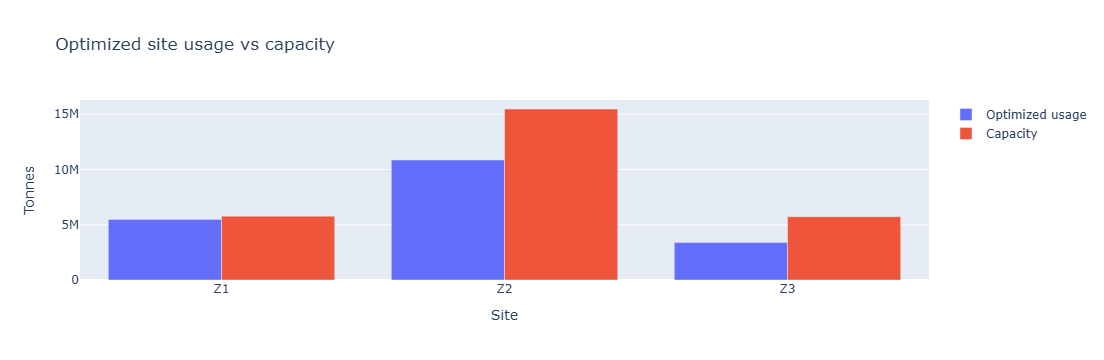

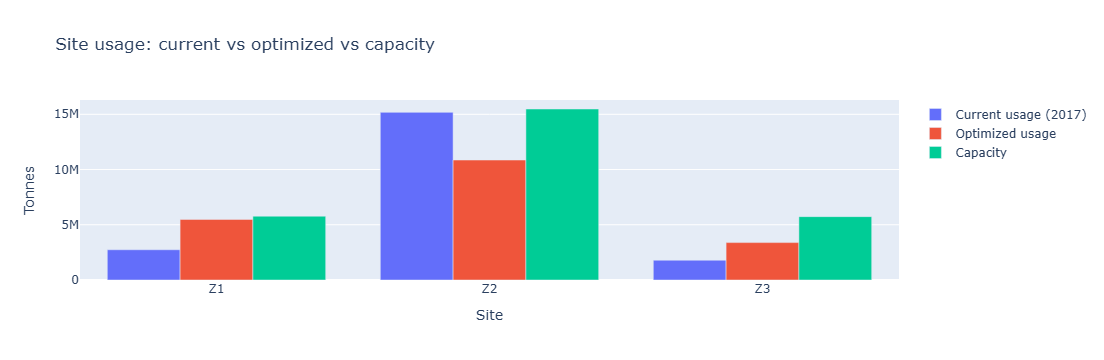

In [48]:
# 8.1 Site usage: current vs optimized vs capacity

# ---------- 1. Rebuild site_df if needed ----------
# Assumes you already have: expedition, site_capacity, flows_opt

sites = ["Z1", "Z2", "Z3"]  # or sorted(site_capacity.keys())

# Current (2017) volume per site
site_volume_current = expedition.groupby("Site")["Weight[t]"].sum()

# Build site_df with volume and capacity
site_df = pd.DataFrame({
    "Volume_t": site_volume_current,
    "Capacity_t": pd.Series(site_capacity)
}).reindex(sites)

# Optimized volume per site from flows_opt
site_volume_opt = flows_opt.groupby("Site")["Tonnes"].sum()
site_volume_opt = site_volume_opt.reindex(sites).fillna(0)

# Extract aligned series
current_volume   = site_df["Volume_t"]
capacity         = site_df["Capacity_t"]
optimized_volume = site_volume_opt

# Percent utilizations
current_pct   = (current_volume / capacity * 100).round(1)
optimized_pct = (optimized_volume / capacity * 100).round(1)
capacity_pct  = np.full(len(sites), 100.0)

# ---------- 2. Plotly: Optimized usage vs capacity ----------

fig_opt = go.Figure()

fig_opt.add_bar(
    x=sites,
    y=optimized_volume,
    name="Optimized usage",
    customdata=np.stack([optimized_pct.values], axis=-1),
    hovertemplate=(
        "Site: %{x}<br>" +
        "Optimized usage: %{y:.0f} t<br>" +
        "Utilization: %{customdata[0]:.1f}%<extra></extra>"
    ),
)

fig_opt.add_bar(
    x=sites,
    y=capacity,
    name="Capacity",
    customdata=np.stack([capacity_pct], axis=-1),
    hovertemplate=(
        "Site: %{x}<br>" +
        "Capacity: %{y:.0f} t<br>" +
        "Utilization: %{customdata[0]:.1f}%<extra></extra>"
    ),
)

fig_opt.update_layout(
    title="Optimized site usage vs capacity",
    xaxis_title="Site",
    yaxis_title="Tonnes",
    barmode="group",
)

fig_opt.show()

# ---------- 3. Plotly: Current vs Optimized vs Capacity ----------

fig_comp = go.Figure()

# Current
fig_comp.add_bar(
    x=sites,
    y=current_volume,
    name="Current usage (2017)",
    customdata=np.stack([current_pct.values], axis=-1),
    hovertemplate=(
        "Site: %{x}<br>" +
        "Current usage: %{y:.0f} t<br>" +
        "Utilization: %{customdata[0]:.1f}%<extra></extra>"
    ),
)

# Optimized
fig_comp.add_bar(
    x=sites,
    y=optimized_volume,
    name="Optimized usage",
    customdata=np.stack([optimized_pct.values], axis=-1),
    hovertemplate=(
        "Site: %{x}<br>" +
        "Optimized usage: %{y:.0f} t<br>" +
        "Utilization: %{customdata[0]:.1f}%<extra></extra>"
    ),
)

# Capacity
fig_comp.add_bar(
    x=sites,
    y=capacity,
    name="Capacity",
    customdata=np.stack([capacity_pct], axis=-1),
    hovertemplate=(
        "Site: %{x}<br>" +
        "Capacity: %{y:.0f} t<br>" +
        "Utilization: %{customdata[0]:.1f}%<extra></extra>"
    ),
)

fig_comp.update_layout(
    title="Site usage: current vs optimized vs capacity",
    xaxis_title="Site",
    yaxis_title="Tonnes",
    barmode="group",
)

fig_comp.show()
fig_comp.write_image("site_usage_2017_vs_optimized.png", width=1600, height=900, scale=3)


### 8.2 Mode split per site – current (2017)

As a reminder, this chart shows how each site used Train vs Truck in 2017 (absolute tonnes).
I will compare it with the optimized mode split in the next step.


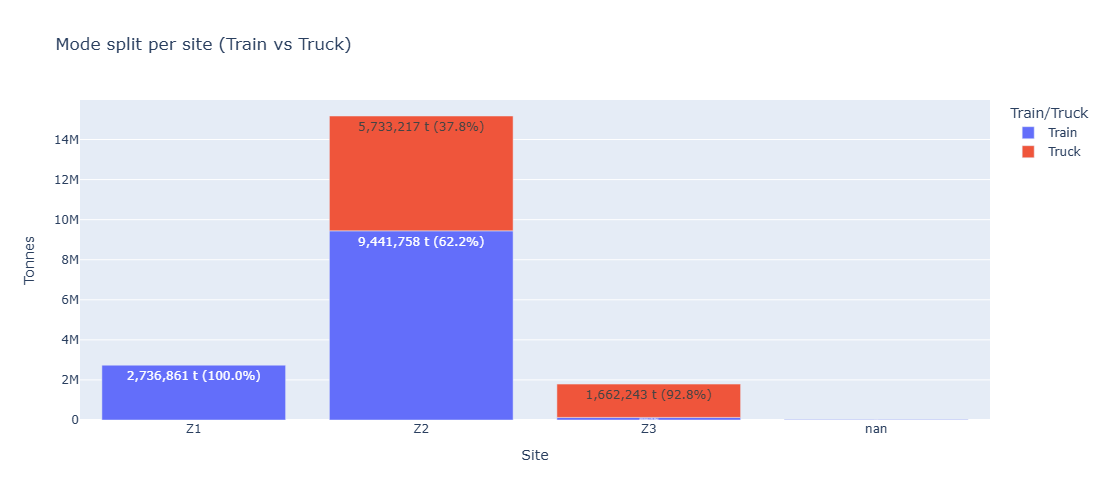

In [49]:
# 8.2 Current (2017) mode split per site – absolute tonnes

# copy + compute % share within each Site
mode_site2 = mode_site.copy()
mode_site2["Pct"] = (
    mode_site2.groupby("Site")["Tonnes"]
    .transform(lambda x: x / x.sum() * 100)
)

# nice text: "2 736 861 t (100.0%)"
mode_site2["Text"] = mode_site2.apply(
    lambda r: f"{r['Tonnes']:,.0f} t\n({r['Pct']:.1f}%)",
    axis=1
)

fig = px.bar(
    mode_site2,
    x="Site",
    y="Tonnes",
    color="Train/Truck",
    title="Mode split per site (Train vs Truck)",
    text="Text",
    width=900,
    height=500
)

fig.update_traces(textposition="inside")
fig.update_layout(
    bargap=0.15,
    bargroupgap=0.05
)

fig.show()
fig.write_image("mode_split_per_site_2017.png", width=1600, height=900, scale=3)


### 8.3 Mode split per site – optimized (absolute tonnes)

Now I compute the **optimized** Train vs Truck split per site:

- Same style as the 2017 chart,
- Shows how much volume each mode carries at each site in the optimized solution.

This lets us visually check that:

- Z1 remains train-heavy,
- Z3 remains truck-heavy,
- and proportions stay realistic.


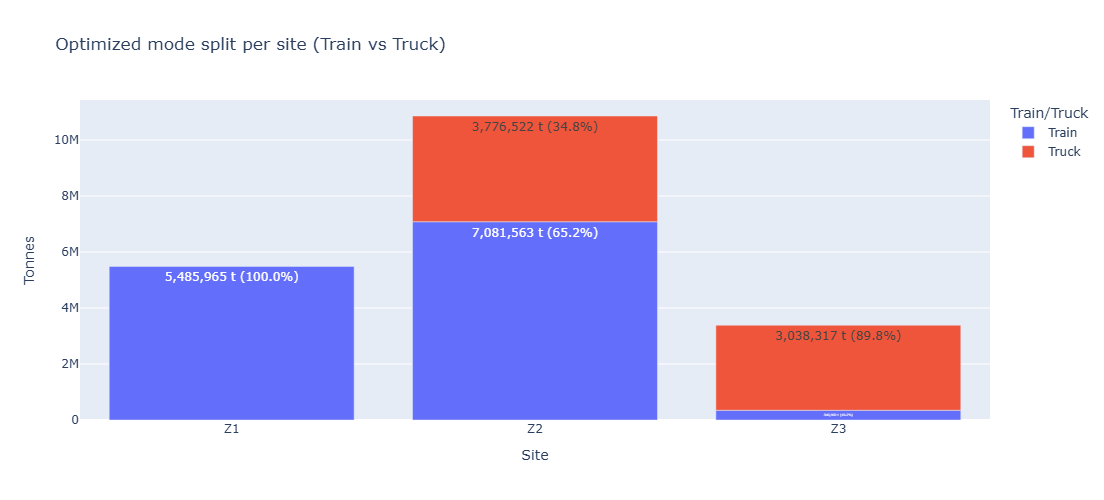

In [50]:
# 8.3 Optimized mode split per site – absolute tonnes

# 1) Aggregate optimized tonnage by Site and Mode
mode_site_opt = (
    flows_opt
    .groupby(["Site", "Mode"])["Tonnes"]
    .sum()
    .reset_index()
)

# For consistency with the old plot (column called "Train/Truck")
mode_site_opt = mode_site_opt.rename(columns={"Mode": "Train/Truck"})

# 2) Compute % share within each Site
mode_site_opt["Pct"] = (
    mode_site_opt.groupby("Site")["Tonnes"]
    .transform(lambda x: x / x.sum() * 100)
)

# 3) Nice text: "2 736 861 t (100.0%)"
mode_site_opt["Text"] = mode_site_opt.apply(
    lambda r: f"{r['Tonnes']:,.0f} t\n({r['Pct']:.1f}%)",
    axis=1
)

# 4) Plotly stacked bar for optimized solution
fig = px.bar(
    mode_site_opt,
    x="Site",
    y="Tonnes",
    color="Train/Truck",
    title="Optimized mode split per site (Train vs Truck)",
    text="Text",
    width=900,
    height=500
)

fig.update_traces(textposition="inside")
fig.update_layout(
    bargap=0.15,
    bargroupgap=0.05
)

fig.show()
fig.write_image("optimized_mode_split_per_site.png", width=1600, height=900, scale=3)


### 8.4 Site-level Train share: 2017 vs optimized (numbers)

Here I numerically compare, for each site:

- the **historical Train share** (2017),
- the **optimized Train share**,

to verify that the site-level Train share constraints (±3 percentage points) are satisfied.


In [51]:
# 8.4 Numerical comparison: historical vs optimized Train share per site

# Optimized site-level mode split
site_mode_opt = (
    flows_opt
    .groupby(["Site", "Mode"])["Tonnes"]
    .sum()
    .unstack(fill_value=0.0)
)

site_mode_opt["Total"] = site_mode_opt.sum(axis=1)
site_mode_opt["Train_share_opt"] = site_mode_opt["Train"] / site_mode_opt["Total"]

print("Historical Train share:")
print(site_train_share_hist)
print("\nOptimized Train share:")
print(site_mode_opt["Train_share_opt"])


Historical Train share:
Site
Z1    1.00
Z2    0.62
Z3    0.07
nan   1.00
dtype: float64

Optimized Train share:
Site
Z1   1.00
Z2   0.65
Z3   0.10
Name: Train_share_opt, dtype: float64


### 8.5 Optimized mode split per site – percentage view

Finally, I plot the **optimized mode split per site in %** (100% stacked bar), similar to the 2017 chart:

- Each site bar sums to 100%,
- You see Train vs Truck share by color,
- Labels show tonnes and percentage.

This makes it easy to visually confirm that the mode mix per site stayed within the required band.


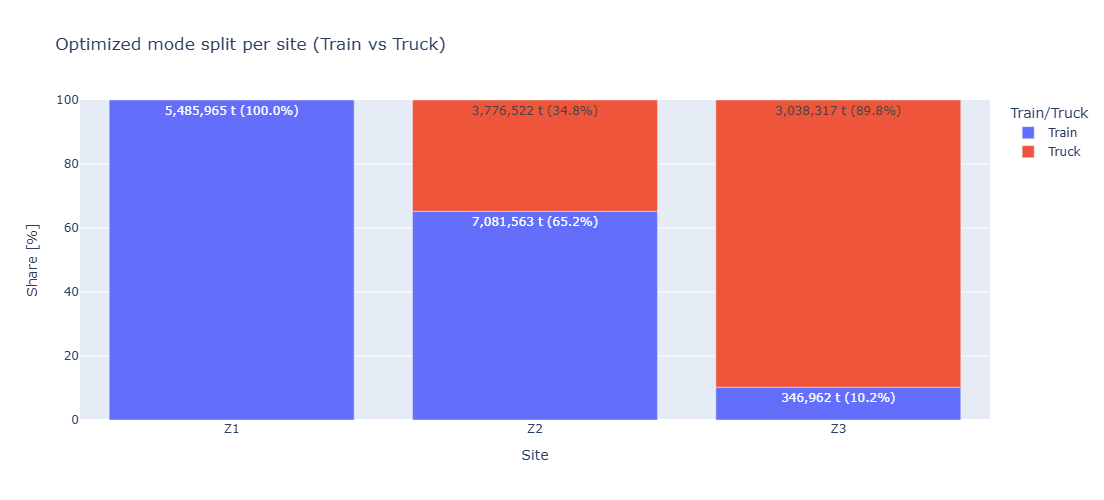

In [52]:
# 8.5 100% stacked bar for optimized solution

# 1) Aggregate optimized tonnage by Site and Mode
mode_site_opt = (
    flows_opt
    .groupby(["Site", "Mode"])["Tonnes"]
    .sum()
    .reset_index()
)

# Match old naming ("Train/Truck") to reuse code style
mode_site_opt = mode_site_opt.rename(columns={"Mode": "Train/Truck"})
mode_site_opt = mode_site_opt[mode_site_opt["Site"].notna()]

# 2) Share of tonnes within each site (in %)
mode_site_opt["Pct"] = (
    mode_site_opt.groupby("Site")["Tonnes"]
    .transform(lambda x: x / x.sum() * 100)
)

# 3) Nice label: "2 736 861 t (100.0%)"
mode_site_opt["Text"] = mode_site_opt.apply(
    lambda r: f"{r['Tonnes']:,.0f} t\n({r['Pct']:.1f}%)",
    axis=1
)

# 4) 100% stacked bar for optimized solution
fig = px.bar(
    mode_site_opt,
    x="Site",
    y="Pct",              # plot percentages so each site sums to 100
    color="Train/Truck",
    title="Optimized mode split per site (Train vs Truck)",
    text="Text",          # show tonnes + %
    width=900,
    height=500
)

fig.update_traces(textposition="inside")

fig.update_layout(
    bargap=0.15,
    bargroupgap=0.05,
)

fig.update_yaxes(title="Share [%]", range=[0, 100])

fig.show()
fig.write_image("optimized_mode_split_per_site_percent.png", width=1600, height=900, scale=3)


## 9. Optimized network analysis

### 9.1 Top customers by tonnage in the optimized network

Now that the optimization model is solved, I look at **who the biggest customers are in the new plan**:

- I aggregate the optimized flows by customer and rank them by total tonnes.
- This is similar to the "Top customers in 2017" chart, but now based on the **optimized flows**.
- It helps to see if the same customers still dominate the volume, or if some customers’ volumes moved between sites/modes.


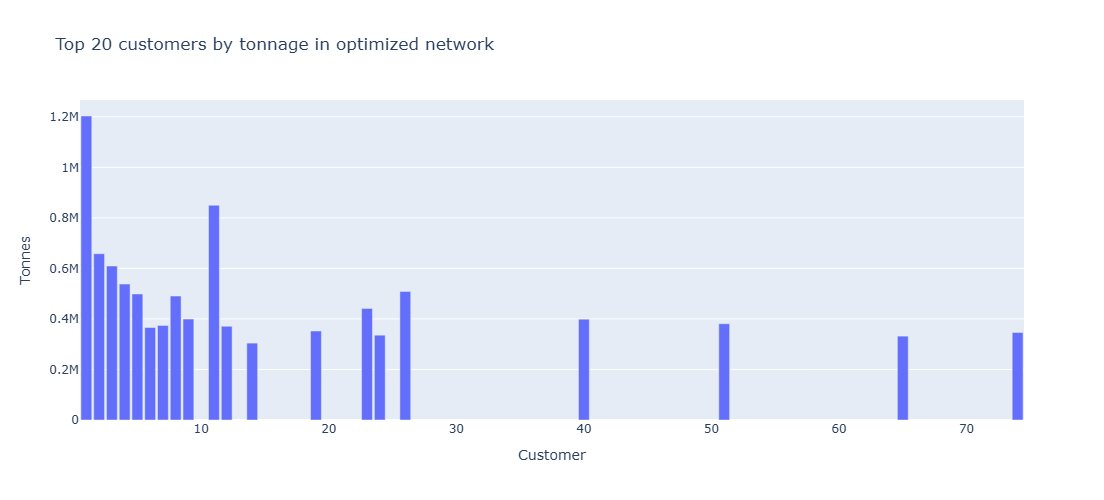

In [53]:
# 9.1 Top customers by optimized tonnage

customer_volume_new = (
    flows_opt.groupby("Customer")["Tonnes"]
    .sum()
    .sort_values(ascending=False)
)

top_n = 20
top_cust_new = customer_volume_new.head(top_n).reset_index()

fig = px.bar(
    top_cust_new,
    x="Customer",
    y="Tonnes",
    title=f"Top {top_n} customers by tonnage in optimized network",
    labels={"Tonnes": "Tonnes"},
    width=1000,
    height=500
)

fig.update_layout(
    bargap=0.15,
)

fig.show()


### 9.2 Extra ton-km vs closest site (optimized network)

I repeat the **extra ton-km** analysis for the optimized network:

For each customer:

- I compute the **extra distance** used vs the closest possible site:
  - `ExtraDistance_km = Distance_km – MinDistance_km`,
  - `Extra_ton_km = Tonnes × ExtraDistance_km`.
- I aggregate `Extra_ton_km` by customer in the optimized flows.
- Then I plot the customers with the **largest residual extra ton-km**.

Ideally, after optimization these values are much lower than in 2017 for most customers, indicating that customers are now assigned to closer sites.


In [54]:
# 9.2 Compute extra ton-km in optimized network

# Attach MinDistance_km to optimized flows
flows_opt2 = flows_opt.merge(
    min_distance_per_customer,
    on="Customer",
    how="left"
)

# Extra distance vs closest site
flows_opt2["ExtraDistance_km"] = flows_opt2["Distance_km"] - flows_opt2["MinDistance_km"]
flows_opt2["ExtraDistance_km"] = flows_opt2["ExtraDistance_km"].clip(lower=0)

# Extra ton-km
flows_opt2["Extra_ton_km"] = flows_opt2["Tonnes"] * flows_opt2["ExtraDistance_km"]

# Aggregate by customer
ineff_per_cust_new = (
    flows_opt2.groupby("Customer")["Extra_ton_km"]
    .sum()
    .sort_values(ascending=False)
)


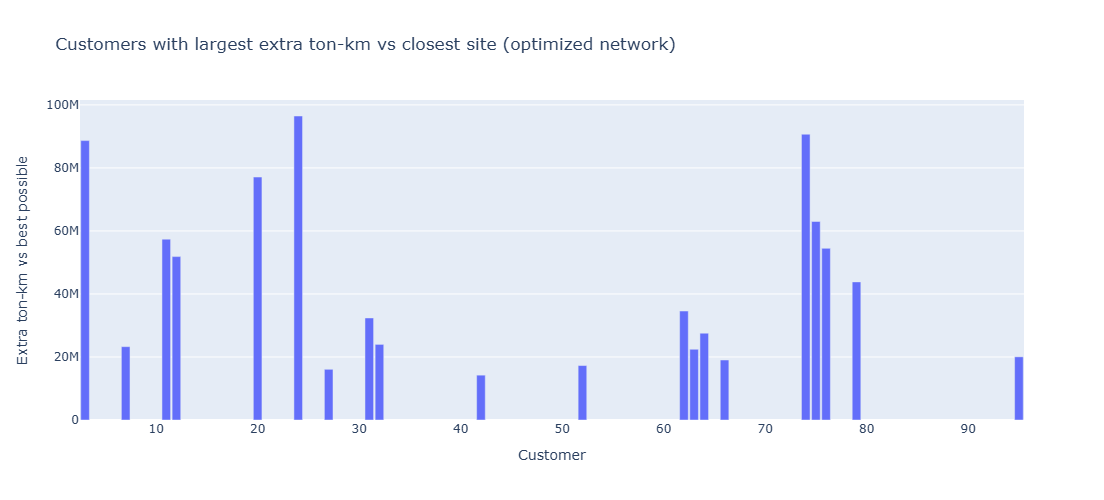

In [55]:
# 9.3 Plot top customers by extra ton-km in optimized network

ineff_top_new = ineff_per_cust_new.head(20).reset_index()

fig = px.bar(
    ineff_top_new,
    x="Customer",
    y="Extra_ton_km",
    title="Customers with largest extra ton-km vs closest site (optimized network)",
    labels={"Extra_ton_km": "Extra ton-km vs best possible"},
    width=1000,
    height=500
)

fig.update_layout(bargap=0.15)

fig.show()


## 10. Customer-level comparison: 2017 vs optimized

Now I build a single comparison table `comp` per customer, with:

- **2017 (current)**:
  - `Tonnes_2017`
  - `Tonkm_2017`
  - `Extra_tonkm_2017` (vs closest site)
  - `Cost_2017_EUR`
- **Optimized**:
  - `Tonnes_opt`
  - `Tonkm_opt`
  - `Extra_tonkm_opt`
  - `Cost_opt_EUR`

Then I:

- focus on the **top 100 customers** by optimized extra ton-km,
- and compare 2017 vs optimized for both extra ton-km and cost.

This is the main quantitative proof of the benefits of the optimization.


In [56]:
# 10.1 Build per-customer comparison: 2017 vs optimized

# ---------- Ensure I have base stuff ----------

# Cost per tkm (same as in model)
# COST_PER_TKM = {"Truck": 0.06, "Train": 0.035}

# 1a) CURRENT NETWORK: recompute extra ton-km & cost if needed
# Make sure ton_km exists in expedition1
if "ton_km" not in expedition1.columns:
    expedition1["ton_km"] = expedition1["Weight[t]"] * expedition1["Distance_km"]

# Min distance per customer (closest site)
min_distance_per_customer = (
    dist_mat.groupby("Customer")["Distance (km)"]
    .min()
    .rename("MinDistance_km")
)

exp_current = expedition1.merge(
    min_distance_per_customer,
    on="Customer",
    how="left"
)

exp_current["ExtraDistance_km"] = exp_current["Distance_km"] - exp_current["MinDistance_km"]
exp_current["ExtraDistance_km"] = exp_current["ExtraDistance_km"].clip(lower=0)
exp_current["Extra_ton_km"] = exp_current["Weight[t]"] * exp_current["ExtraDistance_km"]

# Cost in 2017
exp_current["unit_cost_eur_per_tkm"] = exp_current["Train/Truck"].map(COST_PER_TKM)
exp_current["Cost_EUR"] = exp_current["ton_km"] * exp_current["unit_cost_eur_per_tkm"]

# Aggregate per customer (2017)
agg_current = (
    exp_current.groupby("Customer")
    .agg(
        Tonnes_2017=("Weight[t]", "sum"),
        Tonkm_2017=("ton_km", "sum"),
        Extra_tonkm_2017=("Extra_ton_km", "sum"),
        Cost_2017_EUR=("Cost_EUR", "sum"),
    )
)

# 1b) OPTIMIZED NETWORK: extra ton-km & cost per customer

flows_opt2 = flows_opt.merge(
    min_distance_per_customer,
    on="Customer",
    how="left"
)

flows_opt2["ExtraDistance_km"] = flows_opt2["Distance_km"] - flows_opt2["MinDistance_km"]
flows_opt2["ExtraDistance_km"] = flows_opt2["ExtraDistance_km"].clip(lower=0)
flows_opt2["Extra_ton_km"] = flows_opt2["Tonnes"] * flows_opt2["ExtraDistance_km"]

# Ensure ton_km exists (if not, compute)
if "ton_km" not in flows_opt2.columns:
    flows_opt2["ton_km"] = flows_opt2["Tonnes"] * flows_opt2["Distance_km"]

# Cost already in flows_opt2 as Cost_EUR (if not, recompute)
if "Cost_EUR" not in flows_opt2.columns:
    flows_opt2["Cost_EUR"] = (
        flows_opt2["ton_km"] *
        flows_opt2["Mode"].map(COST_PER_TKM)
    )

agg_opt = (
    flows_opt2.groupby("Customer")
    .agg(
        Tonnes_opt=("Tonnes", "sum"),
        Tonkm_opt=("ton_km", "sum"),
        Extra_tonkm_opt=("Extra_ton_km", "sum"),
        Cost_opt_EUR=("Cost_EUR", "sum"),
    )
)

# 1c) Choose customers: top by optimized extra ton-km
top_n = 100
top_customers = (
    agg_opt["Extra_tonkm_opt"]
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

# 1d) Build comparison DataFrame
comp = (
    agg_current.join(agg_opt, how="inner")
    .loc[top_customers]
    .reset_index()
)

comp


,Customer,Tonnes_2017,Tonkm_2017,Extra_tonkm_2017,Cost_2017_EUR,Tonnes_opt,Tonkm_opt,Extra_tonkm_opt,Cost_opt_EUR
0,24,"335,632.00","111,322,380.00","97,897,100.00","4,651,626.05","335,632.00","109,911,576.40","96,486,296.40","4,422,595.72"
1,74,"346,212.00","142,309,706.00","131,630,764.00","7,962,293.48","346,212.00","101,440,116.00","90,707,544.00","3,550,404.06"
2,3,"609,377.00","219,583,723.00","216,536,838.00","8,363,653.18","609,377.00","91,717,802.60","88,670,917.60","3,225,406.57"
3,20,"287,719.00","113,499,961.00","78,110,524.00","4,877,186.49","287,719.00","112,498,129.00","77,108,692.00","4,686,434.60"
4,75,"179,009.00","89,325,491.00","63,011,168.00","3,726,439.69","179,009.00","89,325,491.00","63,011,168.00","3,614,782.82"
...,...,...,...,...,...,...,...,...,...
95,9,"399,240.00","55,289,416.00","49,700,056.00","2,022,587.76","399,240.00","5,589,360.00",0.00,"229,467.70"
96,69,"217,952.00","26,555,905.00","1,491,425.00","1,360,775.68","217,952.00","25,064,480.00",0.00,"1,339,906.40"
97,70,"275,700.00","96,675,520.00","731,920.00","5,438,217.80","275,700.00","95,943,600.00",0.00,"5,292,671.10"
98,72,"65,361.00","1,137,813.00","288,120.00","53,317.13","65,361.00","849,693.00",0.00,"44,295.05"


### 10.2 Extra ton-km: 2017 vs optimized (top 100 customers)

Here I compare, for the top 100 customers by **optimized extra ton-km**:

- their `Extra_tonkm_2017` vs
- their `Extra_tonkm_opt`.

Each customer has two bars (2017 vs optimized).  
In almost all cases, the optimized bar should be lower (or at worst equal), showing improved site assignment and lower distances.


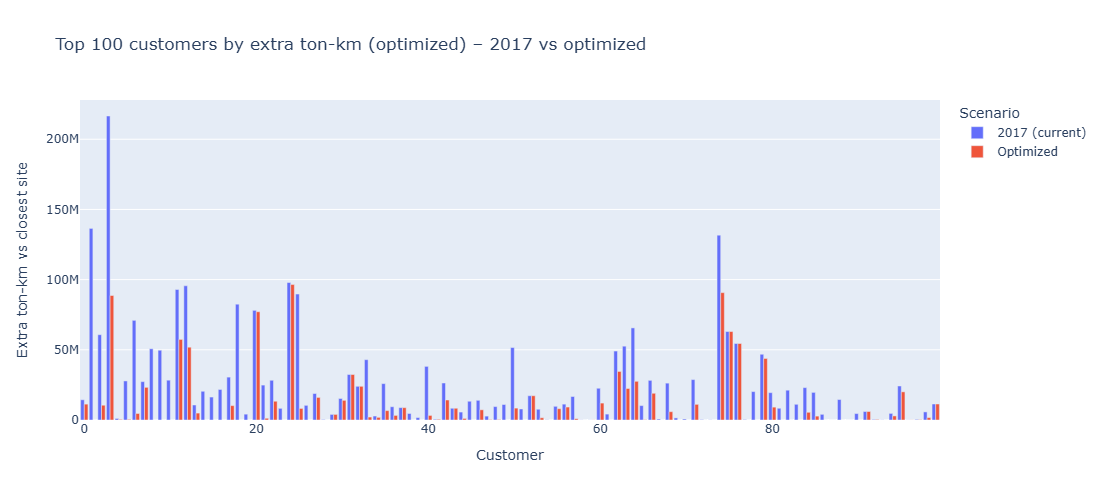

In [57]:
# 10.2 Plot extra ton-km: 2017 vs optimized

# Prepare long format for extra ton-km
extra_long = comp.melt(
    id_vars="Customer",
    value_vars=["Extra_tonkm_2017", "Extra_tonkm_opt"],
    var_name="Scenario",
    value_name="Extra_ton_km"
)

# Nice scenario names
scenario_map = {
    "Extra_tonkm_2017": "2017 (current)",
    "Extra_tonkm_opt": "Optimized",
}
extra_long["Scenario"] = extra_long["Scenario"].map(scenario_map)

fig_extra = px.bar(
    extra_long,
    x="Customer",
    y="Extra_ton_km",
    color="Scenario",
    barmode="group",
    title=f"Top {top_n} customers by extra ton-km (optimized) – 2017 vs optimized",
    labels={"Extra_ton_km": "Extra ton-km vs closest site"},
    width=1100,
    height=500,
)

fig_extra.update_layout(bargap=0.15)

fig_extra.show()
fig_extra.write_image("top100cust_ton_km_compare.png", width=1600, height=900, scale=3)


### 10.3 Cost: 2017 vs optimized (top 100 customers)

Finally, I compare the **cost** per customer, again for the top 100 customers by optimized extra ton-km:

- `Cost_2017_EUR` vs
- `Cost_opt_EUR`.

This shows clearly:

- where the biggest cost savings are,
- and that **no major customer gets more expensive service** in the optimized plan (most bars shift down).

This is usually the most convincing slide for management.


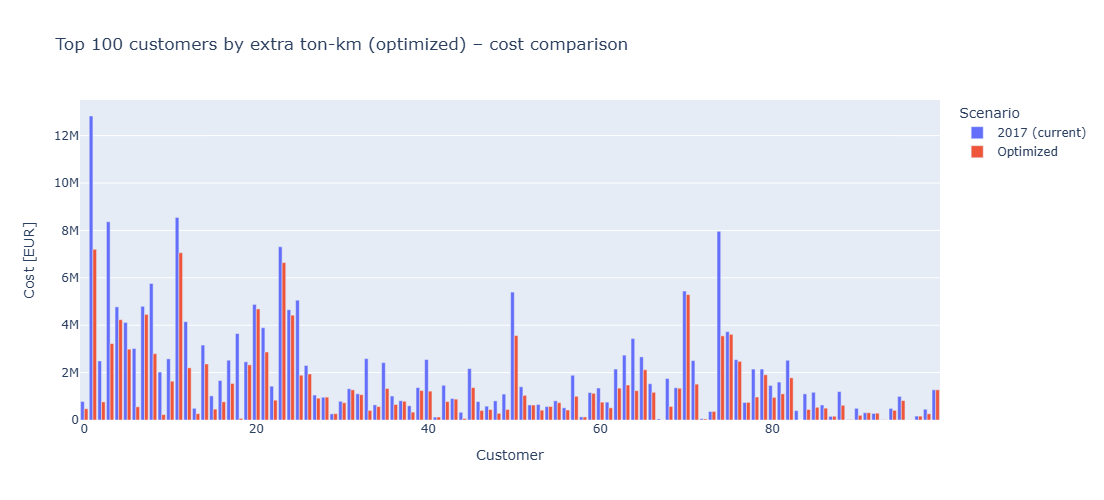

In [58]:
# 10.3 Plot cost: 2017 vs optimized

# Prepare long format for cost
cost_long = comp.melt(
    id_vars="Customer",
    value_vars=["Cost_2017_EUR", "Cost_opt_EUR"],
    var_name="Scenario",
    value_name="Cost_EUR"
)

scenario_map_cost = {
    "Cost_2017_EUR": "2017 (current)",
    "Cost_opt_EUR": "Optimized",
}
cost_long["Scenario"] = cost_long["Scenario"].map(scenario_map_cost)

fig_cost = px.bar(
    cost_long,
    x="Customer",
    y="Cost_EUR",
    color="Scenario",
    barmode="group",
    title=f"Top {top_n} customers by extra ton-km (optimized) – cost comparison",
    labels={"Cost_EUR": "Cost [EUR]"},
    width=1100,
    height=500,
)

fig_cost.update_layout(bargap=0.15)

fig_cost.show()
fig_cost.write_image("top100cust_cost_compare.png", width=1600, height=900, scale=3)


## 11. Cost by site and in total: 2017 vs optimized

First I compare **distribution cost per site**:

- `Cost_2017_EUR` – total 2017 cost for each site,
- `Cost_opt_EUR` – total cost for each site in the optimized plan.

Then I also compute overall totals and plot both **per site** and **Total**.


In [59]:
# 11.1 Cost per site: 2017 vs optimized

# Optimized cost per site
cost_by_site_opt = (
    flows_opt.groupby("Site")["Cost_EUR"]
    .sum()
    .reset_index()
    .rename(columns={"Cost_EUR": "Cost_opt_EUR"})
)

# Current cost per site in DataFrame form
cost_by_site_curr = (
    cost_by_site.reset_index()
    .rename(columns={"Cost_EUR": "Cost_2017_EUR"})
)

# Merge both into one comparison table
cost_comp = cost_by_site_curr.merge(cost_by_site_opt, on="Site", how="inner")
cost_comp


,Site,Cost_2017_EUR,Cost_opt_EUR
0,Z1,"24,155,972.33","31,145,623.74"
1,Z2,"164,201,992.24","84,772,917.63"
2,Z3,"19,330,444.57","20,001,637.67"


### 11.2 Total savings and site breakdown

From the per-site table I calculate:

- **Total 2017 cost**,
- **Total optimized cost**,
- **Absolute savings**,
- **Relative savings (%)**.

Then I add a synthetic row `"Total"` and plot a grouped bar chart:

- bars for Z1, Z2, Z3, and Total,
- each with 2017 vs optimized costs side by side.


Total cost 2017:   207,688,409 EUR
Total cost opt.:   135,920,179 EUR
Savings absolute:  71,768,230 EUR
Savings relative:  34.6 %


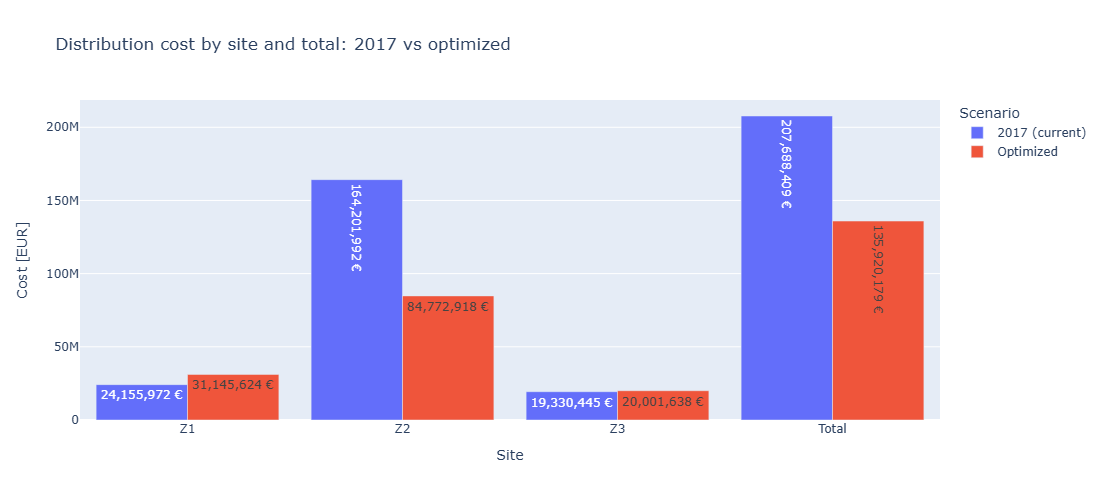

In [60]:
# 11.2 Total cost and savings

total_cost_2017 = cost_comp["Cost_2017_EUR"].sum()
total_cost_opt  = cost_comp["Cost_opt_EUR"].sum()

print(f"Total cost 2017:   {total_cost_2017:,.0f} EUR")
print(f"Total cost opt.:   {total_cost_opt:,.0f} EUR")
print(f"Savings absolute:  {total_cost_2017 - total_cost_opt:,.0f} EUR")
print(f"Savings relative:  {(1 - total_cost_opt / total_cost_2017) * 100:.1f} %")

# --- 2) Add a 'Total' row for plotting ---

total_row = pd.DataFrame({
    "Site": ["Total"],
    "Cost_2017_EUR": [total_cost_2017],
    "Cost_opt_EUR":  [total_cost_opt],
})

cost_comp_with_total = pd.concat([cost_comp, total_row], ignore_index=True)

# --- 3) Build long format for Plotly (sites + total) ---

cost_long = cost_comp_with_total.melt(
    id_vars="Site",
    value_vars=["Cost_2017_EUR", "Cost_opt_EUR"],
    var_name="Scenario",
    value_name="Cost_EUR"
)

scenario_map = {
    "Cost_2017_EUR": "2017 (current)",
    "Cost_opt_EUR": "Optimized",
}
cost_long["Scenario"] = cost_long["Scenario"].map(scenario_map)

# --- 4) Plot comparison (including TOTAL) ---

fig_cost_sites = px.bar(
    cost_long,
    x="Site",
    y="Cost_EUR",
    color="Scenario",
    barmode="group",
    title="Distribution cost by site and total: 2017 vs optimized",
    labels={"Cost_EUR": "Cost [EUR]"},
    width=900,
    height=500,
    text="Cost_EUR"
)

fig_cost_sites.update_traces(
    texttemplate="%{text:,.0f} €",
    textposition="inside"
)

fig_cost_sites.update_layout(bargap=0.15)

fig_cost_sites.show()

fig_cost_sites.write_image("cost_by_site_2017_vs_optimized.png", width=1600, height=900, scale=3)


## 12. Per-customer cost savings

Next I enrich the `comp` table with:

- `Cost_saving_EUR = Cost_2017_EUR – Cost_opt_EUR`,
- `Cost_saving_%` (relative saving per customer).

This makes it easy to inspect which customers generate the largest savings.


In [61]:
# 12. Per-customer savings in euros and percent

comp["Cost_saving_EUR"] = comp["Cost_2017_EUR"] - comp["Cost_opt_EUR"]
comp["Cost_saving_%"] = 100 * comp["Cost_saving_EUR"] / comp["Cost_2017_EUR"]

comp.head()


,Customer,Tonnes_2017,Tonkm_2017,Extra_tonkm_2017,Cost_2017_EUR,Tonnes_opt,Tonkm_opt,Extra_tonkm_opt,Cost_opt_EUR,Cost_saving_EUR,Cost_saving_%
0,24,"335,632.00","111,322,380.00","97,897,100.00","4,651,626.05","335,632.00","109,911,576.40","96,486,296.40","4,422,595.72","229,030.33",4.92
1,74,"346,212.00","142,309,706.00","131,630,764.00","7,962,293.48","346,212.00","101,440,116.00","90,707,544.00","3,550,404.06","4,411,889.42",55.41
2,3,"609,377.00","219,583,723.00","216,536,838.00","8,363,653.18","609,377.00","91,717,802.60","88,670,917.60","3,225,406.57","5,138,246.61",61.44
3,20,"287,719.00","113,499,961.00","78,110,524.00","4,877,186.49","287,719.00","112,498,129.00","77,108,692.00","4,686,434.60","190,751.88",3.91
4,75,"179,009.00","89,325,491.00","63,011,168.00","3,726,439.69","179,009.00","89,325,491.00","63,011,168.00","3,614,782.82","111,656.86",3.00


In [62]:
maxx = comp[['Cost_saving_%']].max()

maxx

Cost_saving_%   99.27
dtype: float64

In [63]:
top13_rows = comp.nlargest(13, "Cost_saving_%")
top13_rows


,Customer,Tonnes_2017,Tonkm_2017,Extra_tonkm_2017,Cost_2017_EUR,Tonnes_opt,Tonkm_opt,Extra_tonkm_opt,Cost_opt_EUR,Cost_saving_EUR,Cost_saving_%
69,83,"82,451.00","11,263,511.00","11,181,060.00","394,849.74","82,451.00","82,451.00",0.00,"2,885.79","391,963.95",99.27
82,18,"247,476.00","83,969,817.00","82,484,961.00","3,648,165.52","247,476.00","1,484,856.00",0.00,"66,361.38","3,581,804.14",98.18
95,9,"399,240.00","55,289,416.00","49,700,056.00","2,022,587.76","399,240.00","5,589,360.00",0.00,"229,467.70","1,793,120.06",88.65
47,33,"130,243.00","47,904,623.00","42,955,389.00","2,588,957.60","130,243.00","7,040,946.85","2,091,712.85","403,311.60","2,185,646.00",84.42
77,67,"142,766.00","823,818.00","681,052.00","44,174.00","142,766.00","142,766.00",0.00,"7,042.84","37,131.16",84.06
41,6,"366,039.00","78,676,945.00","70,990,126.00","3,014,682.60","366,039.00","12,333,802.50","4,646,983.50","556,893.48","2,457,789.12",81.53
52,44,"46,883.00","6,077,173.00","5,655,226.00","326,346.98","46,883.00","1,542,007.50","1,120,060.50","62,580.37","263,766.61",80.82
26,2,"658,083.00","69,964,950.00","60,751,788.00","2,491,358.00","658,083.00","19,742,490.00","10,529,328.00","764,590.01","1,726,767.99",69.31
38,68,"171,653.00","32,950,941.00","26,256,474.00","1,750,383.73","171,653.00","12,611,735.70","5,917,268.70","573,159.23","1,177,224.50",67.26
58,48,"69,431.00","14,072,776.00","9,559,761.00","806,457.76","69,431.00","4,875,446.55","362,431.55","281,001.77","525,455.99",65.16


## 13. Optimized main flows (Sankey)

Finally, I build a **Sankey diagram** for the optimized network, similar to the one for 2017:

- Nodes on the left: sites (Z1, Z2, Z3),
- Nodes on the right: **top 20 customers** by optimized tonnage,
- Link widths ∝ tonnes.

By comparing this Sankey to the 2017 one, we can visually see how flows shifted between sites and customers in the optimized solution.


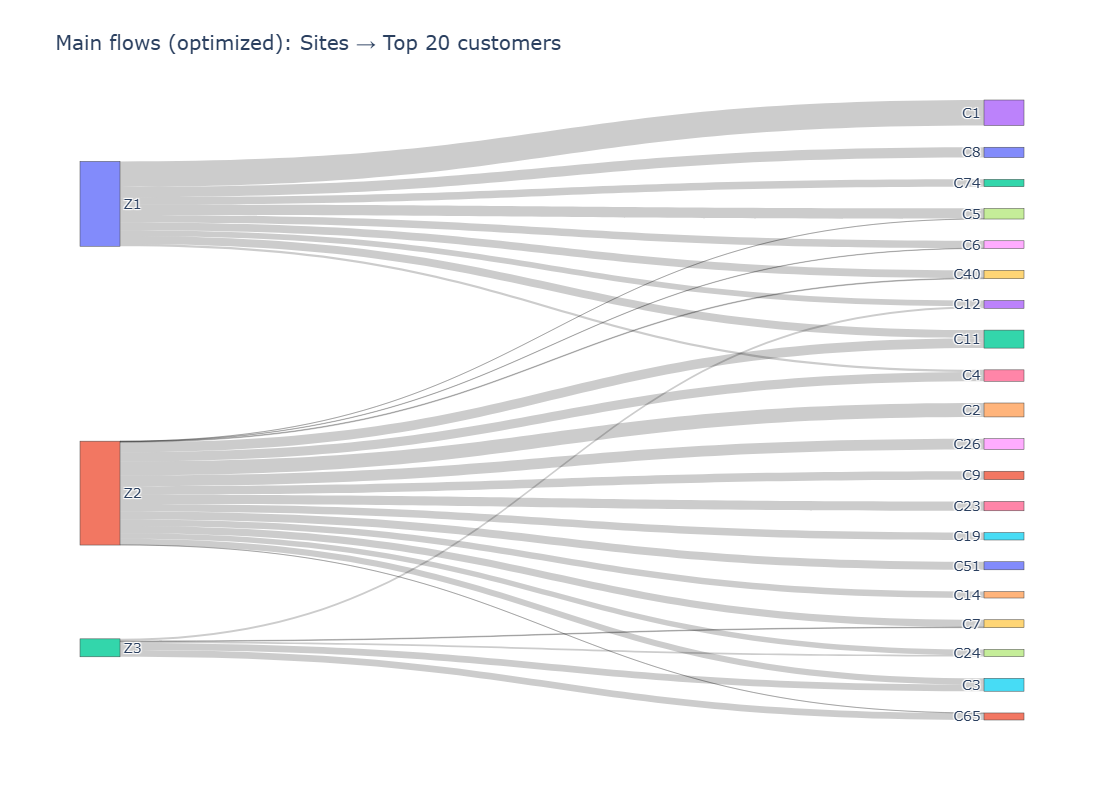

In [64]:
# 13. Optimized main flows: Sites → Top customers (Sankey)

# 1) Aggregate optimized flows Site → Customer
cust_site_flows_opt = (
    flows_opt.groupby(["Site", "Customer"])["Tonnes"]
    .sum()
    .reset_index()
)

# 2) Only keep top N customers by optimized volume to keep diagram readable
top_n = 20
top_customers_for_sankey_opt = (
    cust_site_flows_opt.groupby("Customer")["Tonnes"]
    .sum()
    .nlargest(top_n)
    .index
)

cs_top_opt = cust_site_flows_opt[
    cust_site_flows_opt["Customer"].isin(top_customers_for_sankey_opt)
]

# 3) Build nodes: first sites, then customers
sites_opt = cs_top_opt["Site"].unique().tolist()
customers_opt = sorted(cs_top_opt["Customer"].unique())

site_nodes_opt = sites_opt
customer_nodes_opt = [f"C{c}" for c in customers_opt]
nodes_opt = site_nodes_opt + customer_nodes_opt

node_indices_opt = {name: i for i, name in enumerate(nodes_opt)}

sources_opt = [node_indices_opt[row["Site"]] for _, row in cs_top_opt.iterrows()]
targets_opt = [node_indices_opt[f"C{row['Customer']}"] for _, row in cs_top_opt.iterrows()]
values_opt = cs_top_opt["Tonnes"].tolist()

# 4) Plot Sankey for optimized flows
fig_opt_sankey = go.Figure(data=[go.Sankey(
    node=dict(
        pad=30,
        thickness=40,
        label=nodes_opt,
    ),
    link=dict(
        source=sources_opt,
        target=targets_opt,
        value=values_opt
    )
)])

fig_opt_sankey.update_layout(
    title_text=f"Main flows (optimized): Sites → Top {top_n} customers",
    width=1100,
    height=800,
    font=dict(size=14)
)

fig_opt_sankey.show()
fig_opt_sankey.write_image("main_flows_site_top_cust_optimized.png", width=1600, height=900, scale=3)


## 14. Summary tables for reporting

### 14.1 Site usage: current vs optimized vs capacity

For the Excel output and for management reporting, I build a simple table `site_usage`:

- `Site`
- `Current_tonnes` – 2017 shipped volume per site,
- `Optimized_tonnes` – volume per site in the optimized plan,
- `Capacity_tonnes` – nominal annual capacity of each site.

This table complements the charts and can be used directly in a report.


In [65]:
# 14.1 Build site_usage: current vs optimized vs capacity

# Current (2017) volume per site
site_volume_current = (
    expedition.groupby("Site")["Weight[t]"]
    .sum()
)

# Optimized volume per site
site_volume_opt = (
    flows_opt.groupby("Site")["Tonnes"]
    .sum()
)

site_usage = pd.DataFrame({
    "Site": site_volume_current.index,
    "Current_tonnes": site_volume_current.values,
}).set_index("Site")

site_usage["Optimized_tonnes"] = site_volume_opt
site_usage["Capacity_tonnes"] = pd.Series(site_capacity)

site_usage = site_usage.reset_index()
site_usage.head()


,Site,Current_tonnes,Optimized_tonnes,Capacity_tonnes
0,Z1,"2,736,861.00","5,485,965.00","5,774,700.00"
1,Z2,"15,174,975.00","10,858,084.65","15,478,400.00"
2,Z3,"1,792,159.00","3,385,278.35","5,734,900.00"
3,nan,"25,333.00",NaN,NaN


### 14.2 Mode split per site: 2017 vs optimized (absolute tonnes)

Next, I build `mode_split_both`, a table that combines:

- **2017** tonnes by `(Site, Train/Truck)` → `Tonnes_2017`
- **Optimized** tonnes by `(Site, Train/Truck)` → `Tonnes_opt`

This table shows how the absolute volumes per mode and site changed after optimization.


In [66]:
# 14.2 Mode split per site – 2017 vs optimized (tonnes)

# 2017
mode_site_2017 = (
    expedition.groupby(["Site", "Train/Truck"])["Weight[t]"]
    .sum()
    .reset_index()
    .rename(columns={"Weight[t]": "Tonnes_2017"})
)

# Optimized
mode_site_opt = (
    flows_opt.groupby(["Site", "Mode"])["Tonnes"]
    .sum()
    .reset_index()
    .rename(columns={"Mode": "Train/Truck", "Tonnes": "Tonnes_opt"})
)

mode_split_both = (
    mode_site_2017
    .merge(mode_site_opt, on=["Site", "Train/Truck"], how="outer")
    .fillna(0)
)

mode_split_both.head()


,Site,Train/Truck,Tonnes_2017,Tonnes_opt
0,Z1,Train,"2,736,861.00","5,485,965.00"
1,Z2,Train,"9,441,758.00","7,081,563.07"
2,Z2,Truck,"5,733,217.00","3,776,521.58"
3,Z3,Train,"129,916.00","346,961.70"
4,Z3,Truck,"1,662,243.00","3,038,316.65"


### 14.3 Mode split per site: 2017 vs optimized (percentages)

Finally, I compute a percentage version `mode_split_pct`:

- For each site:
  - `Pct_2017` – share of each mode in 2017 (in %),
  - `Pct_opt` – share of each mode in the optimized solution (in %).

Together with `Tonnes_2017` and `Tonnes_opt`, this lets us see both the *absolute* and *relative* mode changes per site.


In [67]:
# 14.3 Mode split per site – 2017 vs optimized (percentages)

# 2017 percentages
ms_pct_2017 = mode_site_2017.copy()
ms_pct_2017["Pct_2017"] = (
    ms_pct_2017.groupby("Site")["Tonnes_2017"]
    .transform(lambda x: x / x.sum() * 100)
)

# optimized percentages
ms_pct_opt = mode_site_opt.copy()
ms_pct_opt["Pct_opt"] = (
    ms_pct_opt.groupby("Site")["Tonnes_opt"]
    .transform(lambda x: x / x.sum() * 100)
)

mode_split_pct = (
    ms_pct_2017[["Site", "Train/Truck", "Tonnes_2017", "Pct_2017"]]
    .merge(
        ms_pct_opt[["Site", "Train/Truck", "Tonnes_opt", "Pct_opt"]],
        on=["Site", "Train/Truck"],
        how="outer"
    )
    .fillna(0)
)

mode_split_pct.head()


,Site,Train/Truck,Tonnes_2017,Pct_2017,Tonnes_opt,Pct_opt
0,Z1,Train,"2,736,861.00",100.00,"5,485,965.00",100.00
1,Z2,Train,"9,441,758.00",62.22,"7,081,563.07",65.22
2,Z2,Truck,"5,733,217.00",37.78,"3,776,521.58",34.78
3,Z3,Train,"129,916.00",7.25,"346,961.70",10.25
4,Z3,Truck,"1,662,243.00",92.75,"3,038,316.65",89.75


## 15. Export all results to Excel

To make the results easy to share and further explore, I export the main tables to an Excel file:

**File:** `distribution_optimization_results_new_134.xlsx`

**Sheets:**

- `Flows_detail` – one row per (Customer, Site, Mode) in the optimized plan.
- `Customer_summary` – per-customer totals (tonnes, ton-km, cost).
- `Site_summary` – per-site totals (tonnes, ton-km, cost).
- `Site_Mode_summary` – per (site, mode) totals.
- `Site_usage_curr_vs_opt` – site usage in tonnes: current vs optimized vs capacity.
- `Mode_split_site_2017_opt` – mode split per site: 2017 vs optimized (tonnes).
- `Mode_split_pct_2017_opt` – mode split per site: 2017 vs optimized (percentages).
- `Customer_extra_tonkm_cost` – customer-level comparison (extra ton-km and costs: 2017 vs optimized, with savings).

This Excel is essentially the “deliverable” that management can use as a dashboard and for further analysis.


In [68]:
# 15. Export all key tables to Excel

output_file = "distribution_optimization_results.xlsx"

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    # Detailed flows (one row per customer–site–mode)
    flows_opt.to_excel(writer, sheet_name="Flows_detail", index=False)

    # Summaries
    cust_summary.to_excel(writer, sheet_name="Customer_summary", index=False)
    site_summary.to_excel(writer, sheet_name="Site_summary", index=False)
    site_mode_summary.to_excel(writer, sheet_name="Site_Mode_summary", index=False)

    # Additional comparison sheets
    site_usage.to_excel(writer, sheet_name="Site_usage_curr_vs_opt", index=False)
    mode_split_both.to_excel(writer, sheet_name="Mode_split_site_2017_opt", index=False)
    mode_split_pct.to_excel(writer, sheet_name="Mode_split_pct_2017_opt", index=False)
    comp.to_excel(writer, sheet_name="Customer_extra_tonkm_cost", index=False)

print("Results exported to:", output_file)


Results exported to: distribution_optimization_results_new_135_try.xlsx
